# Multi-cell analysis: LiFi 1.0 (LED) vs LiFi 2.0 (VCSEL)

This notebook extends the single-cell analysis to a multi-cell scenario: several access points (APs) sit on the ceiling, each creating its own cell, and the cells now interfere with each other.

Comparing the two technologies at some arbitrary equal power doesn't make much sense here, because their transmit powers differ by orders of magnitude for reasons that have nothing to do with communications: the LED's watts pay for room lighting, the VCSEL's are capped by eye safety. So instead of fixing a power, this analysis fixes a **service level** (a coverage or rate target) and asks what deployment each technology needs to reach it.

Every paper cited in this notebook is stored in the [`sources/`](sources/) folder.


**Table of contents**

- [1. Introduction](#1.-Introduction)
- [2. System model](#2.-System-model)
    - [2.1 Scenario and transmission models](#2.1-Scenario-and-transmission-models)
    - [2.2 The eye-safety budget: consistent with the single-cell notebook](#2.2-The-eye-safety-budget:-consistent-with-the-single-cell-notebook)
    - [2.3 Channel, association, SINR and capacity](#2.3-Channel,-association,-SINR-and-capacity)
    - [2.4 Implementation](#2.4-Implementation)
    - [2.5 Directivity: the two transmitters side by side](#2.5-Directivity:-the-two-transmitters-side-by-side)
    - [2.6 Metrics](#2.6-Metrics)
    - [2.7 Traceability of every decision](#2.7-Traceability-of-every-decision)
- [3. Case 1 - equal coverage target](#3.-Case-1---equal-coverage-target)
- [4. Case 2 - equal infrastructure](#4.-Case-2---equal-infrastructure)
- [5. Case 3 - cross-equivalence](#5.-Case-3---cross-equivalence)
- [6. Case 4 - scalability and densification](#6.-Case-4---scalability-and-densification)
- [7. Cooperative networks](#7.-Cooperative-networks)
- [8. Results and discussion](#8.-Results-and-discussion)
- [9. Conclusions](#9.-Conclusions)
- [10. Limitations](#10.-Limitations)
- [11. References](#11.-References)

## 1. Introduction

| | **LiFi 1.0 (LED)** | **LiFi 2.0 (VCSEL)** |
|---|---|---|
| Bandwidth | 20 MHz: rate is capped no matter the power (`[RIS-VLC]` Table III) | 2 GHz (`[VCSEL-Precoding]` Table I); 18 GHz devices already exist (`[VCSEL-70Gbps]`) |
| Directivity | very low: a wide Lambertian lobe, good for lighting, but it gives energy into neighbouring cells | very high: a narrow Gaussian beam that does not reach the next cell |
| Power limit | fixed by the illumination requirement, a room-level constraint | fixed by eye safety, a per-source constraint in the milliwatt range |
| Architecture | one emitter per AP, the luminaire itself | dense arrays of emitters (`[VCSEL-Precoding]`: 4x4-8x8 at 10 um pitch) |

The single-cell notebook already showed neither technology works alone: one LED covers only its FoV disk (35% of the room), and one VCSEL covers almost nothing. So the real question is a network one, not a single-link one: how many APs, how much power, how much interference.

---

## 2. System model

### 2.1 Scenario and transmission models

The room is 5 x 5 x 3 m.

APs sit on the ceiling (height 3 m) in an N x N lattice. N = 2-4 is the main comparison range, generalizing the 2x2 benchmark of `[RIS-VLC]` into the natural design space for densification. 

Users are a uniform grid of receivers on the desk plane (height 1 m, $\Delta z$ = 2 m below the ceiling), 200 x 200 points, all pointing straight up with no blockage. The receiver is identical for both technologies ($A_{PD}$ = 1 cm^2, FoV $\Psi_c$ = 40 deg, concentrator $n$ = 1.5), the same unification from the single-cell notebook, since the FoV belongs to the photodiode, not the source.

**LiFi 1.0: LED AP.** Each AP is a single Lambertian emitter ($m$ = 0.40). Its power is set so the deployment meets the lighting standard: average illuminance at least 500 lux, peak at most 800 lux, uniformity at least 0.5 (`[RIS-VLC]` eqs. (24)-(26), constraints C5-C8). So the total optical power is fixed by the room itself; adding more APs just splits the same lighting budget, not more power. 500 lux is the standard's floor, not a rigid single point. This notebook checks the 500 lux average and the 800 lux peak (Section 3 flags the one density where the peak is exceeded); it does not enforce the uniformity >= 0.5 constraint, since that would need optimizing AP placement, not just power, and is beyond what this transmitter-vs-transmitter comparison needs (Section 10).

**LiFi 2.0: VCSEL AP.** Each AP is an array of $M = m \times m$ emitters whose beams tile the AP's cell, with beam selection: only the emitter aimed closest to the user turns on. "Total beams" ($N_{AP}\times M^2$) is this technology's deployment-cost unit, the same role watts plays for LiFi 1.0: it is the count of individually-selectable emitters across the whole deployment, not a measure of power. Full precoding would need channel state information and multi-user scheduling, which is beyond what this comparison of transmitter architectures needs, so beam selection stands in as a simplified form of beam steering. It's conservative relative to `[VCSEL-Precoding]`'s own precoding, which has more degrees of freedom to exploit.

A VCSEL is a coherent emitter (unlike an LED's incoherent spontaneous emission): that spatial coherence is exactly what gives it a narrow, well-defined Gaussian beam instead of a Lambertian glow. This notebook only uses that coherence for the *emission* itself: both technologies still use IM/DD (information carried in intensity), and no phase-based modulation or detection is assumed anywhere below. This also applies to Section 7's cooperative combining: APs there add optical *amplitudes* before square-law detection, which needs synchronized emission, not phase-coded data.

### 2.2 The eye-safety budget: consistent with the single-cell notebook

The VCSEL's per-emitter power is the same eye-safe ceiling derived in the single-cell notebook (Section 4.2): the `[Eye-Safety]` Algorithm 1 + eq. (36) methodology, at the same $w_0 = 5\ \mu m$ waist. Both notebooks compute it with the identical function, so the two are directly comparable.

- $w_0 = 0.45\ \mu m$ (`[VCSEL-Precoding]` Table I) is rejected for the same reason as in the single-cell notebook: it is smaller than the wavelength itself, breaking the paraxial regime the Gaussian-beam model assumes.
- At $w_0 = 5\ \mu m$, the realistic value `[Eye-Safety]` itself uses in its own worked examples (Figs. 7, 9, 13, 16-18), the ceiling comes out to **2.49 mW per active emitter**. Beam selection only ever turns on one emitter at a time, so that emitter gets the full 2.49 mW: the array buys the ability to aim, not more power.
- `[VCSEL-70Gbps]` independently operates a real 940 nm VCSEL at about 5 mW - roughly 2x the computed ceiling. 

`[Eye-Safety]` (Sec. III-C) classifies sources by their angular subtense ($\alpha_{min}$ = 1.5 mrad, $\alpha_{max}$ = 100 mrad, with the MPE (maximum permissible exposure) relaxed for extended sources via $C_6$). Applied here: APs sit metres apart, so each gets an independent eye-safety budget; emitters inside one AP sit only 10 um apart, so they share a single budget.

### 2.3 Channel, association, SINR and capacity

The channel models are the same ones validated in the single-cell notebook: the LED follows the Lambertian LOS model (`[RIS-VLC]` eq. (1)), and the VCSEL follows the Gaussian-beam model (`[VCSEL-Precoding]` eqs. (2)-(8)), with $r$ now the distance to that specific beam's axis. The FoV test still uses the angle to the AP itself, since that's where the light physically comes from. Both models are LOS only and share the same concentrator gain $G$ (`[VCSEL-Precoding]` eq. (8)).

Each user is associated with the AP giving the strongest received power, $s(\mathbf{u}) = \arg\max_i P_i H_i(\mathbf{u})$. This best-server rule is a standard cellular convention and it avoids pulling in scheduling algorithms that aren't the point of this comparison.

The SINR follows the structure of `[VCSEL-Precoding]` eq. (11):

$$\gamma = \frac{(\rho P_s H_s)^2}{N_0 B + \sum_{i\neq s}(\rho P_i H_i)^2}$$

One thing the $N_0 B$ term hides: the VCSEL's 100x wider bandwidth also means 20 dB more noise power, so that bandwidth advantage isn't free.

Interference behaves very differently for the two technologies, even though both use the SINR expression above ($\gamma = S/(N+I)$):

- **LiFi 1.0:** every LED AP transmits continuously and its wide Lambertian lobe reaches well past its own cell, so a user usually picks up interfering power $H_i$ from several neighbouring APs at once. The interference term $\sum_{i\neq s}(\rho P_i H_i)^2$ just sums over every neighbour's Lambertian gain at the user.
- **LiFi 2.0:** an interfering AP has only one beam active at a time, aimed at its own unknown user, and that beam is unlikely to point anywhere near our user; most of the time its contribution is close to zero. This needs its own modelling choice: assuming users are spread uniformly within each cell, the expected interfering gain is the average over the AP's $M$ candidate beam directions. 

The achievable rate uses the same IM/DD lower bound as the single-cell notebook, from `[Capacity-Bound]` and used by both reference papers: $R = \frac{B}{2}\log_2(1 + \frac{e}{2\pi}\gamma)$. Classical Shannon capacity doesn't apply here, since the transmitted signals are real and non-negative, not complex.

### 2.4 Implementation

The cell below builds the AP lattice, the VCSEL beam grid inside each AP, and the association/SINR/rate pipeline described above.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# scenario
ROOM = 5.0; AREA = ROOM**2
dz = 3.0 - 1.0 # AP 3 m, receiver 1 m  - [RIS-VLC] Table III

# unified receiver
APD = 1e-4                            # [RIS-VLC] Table III = [VCSEL-Precoding] Table I
RHO = 1.0                             # same in both papers
PSI_C = np.deg2rad(40.0)              # [RIS-VLC] Table III
G_CONC = 1.5**2 / np.sin(PSI_C)**2    # [VCSEL-Precoding] eq. (8)
R_FOV = dz * np.tan(PSI_C)            # FoV footprint radius on the desk plane

# transmitters
M_LED = -1.0 / np.log2(np.cos(np.deg2rad(80.0)))   # Lambertian order - [RIS-VLC] eq. (1), Table III
LAMBDA = 950e-9                                    # [VCSEL-Precoding] Table I
W0 = 5e-6                                          # [Eye-Safety] Figs. 7,9,13,16-18  (see Sec. 2.2)
W0_PAPER = 0.45e-6                                 # [VCSEL-Precoding] Table I - sub-wavelength, rejected

# eye-safe power per active emitter, ported from the single-cell notebook's
# eye_safe_ptx() -- same w0, same [Eye-Safety] Algorithm 1 + eq. (36) -- so both
# notebooks compute the identical primary VCSEL power, not just a similar one
def mpe_point_long_exposure(lam_nm):
    C4 = 10**(0.002 * (lam_nm - 700))
    C7 = 1.0 if lam_nm < 1150 else 10**(0.018 * (lam_nm - 1150))
    return 10 * C4 * C7  # MPE [W/m^2], [Eye-Safety] Table 4

def eye_safe_ptx(w0, lam, rp=3.5e-3):
    zR_ = np.pi * w0**2 / lam
    theta_div = lam / (np.pi * w0)
    d86 = (np.pi * w0 / lam) * np.sqrt(-2 * rp**2 / np.log(1 - 0.86))
    if 2 * theta_div > 0.092 and d86 < 0.1:
        zhaz = 0.1
    else:
        alpha = 2 * np.arctan(w0 / d86)
        zhaz = 2 * w0 / 0.0021 if alpha < 1.5e-3 else 9.2 * np.pi * w0 / (2 * lam)
    Wzhaz = w0 * np.sqrt(1 + (zhaz / zR_)**2)
    eta = 1 - np.exp(-2 * rp**2 / Wzhaz**2)
    return (1 / eta) * mpe_point_long_exposure(lam * 1e9) * np.pi * rp**2, zhaz, eta

P_VCSEL, _, _ = eye_safe_ptx(W0, LAMBDA)  # [Eye-Safety] Algorithm 1 + eq. (36), same as single-cell Sec. 4.2

# link
N0 = 2.5e-20                          # [RIS-VLC] Table III
B_LED, B_VCSEL = 20e6, 2e9            # [RIS-VLC] Table III / [VCSEL-Precoding] Table I
K_BOUND = np.e / (2*np.pi)            # [Capacity-Bound]
KE_V = 280.0                          # [RIS-VLC] Table III
E_TARGET, E_MAX = 500.0, 800.0        # lighting constraints C5, C8 - [RIS-VLC] Table III
GAMMA_TH_DB = 20.0                    # inside the [10,50] dB range of [RIS-VLC] Table III
GAMMA_TH = 10**(GAMMA_TH_DB/10)
COV_TARGET = 95.0                     # service objective (own choice)

NG = 200
X, Y = np.meshgrid(np.linspace(0, ROOM, NG), np.linspace(0, ROOM, NG))

def ap_lattice(n):
    c = (np.arange(n) + 0.5) * ROOM / n
    xx, yy = np.meshgrid(c, c)
    return np.column_stack([xx.ravel(), yy.ravel()])

def H_led(ap, with_rx=True):
    r = np.hypot(X-ap[0], Y-ap[1]); d = np.sqrt(r**2 + dz**2); th = np.arctan2(r, dz)
    H = (M_LED+1)*APD/(2*np.pi*d**2) * np.cos(th)**M_LED * np.cos(th)   # [RIS-VLC] eq. (1)
    return H if not with_rx else np.where(th <= PSI_C, H*G_CONC, 0.0)

def led_power(aps):
    # per-LED power for 500 lux average - [RIS-VLC] eqs. (24)-(25), C5
    E_per_W = KE_V * np.sum([H_led(a, with_rx=False) for a in aps], axis=0) / APD
    P = E_TARGET / E_per_W.mean()
    return P, P * E_per_W

def vcsel_ap_gains(ap, n_ap, m, w0=W0):
    # AP with m x m beams tiling its cell
    # Returns the best-aimed beam's gain (signal, via beam selection)
    # and the mean over beams (expected interference when it serves someone else)
    zR = np.pi*w0**2/LAMBDA                                   # [VCSEL-Precoding] eq. (2)
    r_ap = np.hypot(X-ap[0], Y-ap[1]); d = np.sqrt(r_ap**2 + dz**2)
    in_fov = np.arctan2(r_ap, dz) <= PSI_C                    # FoV test at the AP
    wz = w0*np.sqrt(1 + (d/zR)**2)                            # [VCSEL-Precoding] eq. (6)
    cell = ROOM/n_ap
    off = (np.arange(m)+0.5)*cell/m - cell/2
    ox, oy = np.meshgrid(off, off)
    g_best = np.zeros_like(X); g_sum = np.zeros_like(X)
    for sx, sy in zip(ap[0]+ox.ravel(), ap[1]+oy.ravel()):
        rb = np.hypot(X-sx, Y-sy)                             # distance to THIS beam's axis
        g = np.where(in_fov, 2/(np.pi*wz**2)*np.exp(-2*rb**2/wz**2)*APD*G_CONC, 0.0)
        g_best = np.maximum(g_best, g); g_sum += g
    return g_best, g_sum/(m*m)

def evaluate_led(n, coop="none", margin_dB=3.0):
    aps = ap_lattice(n); P, Ev = led_power(aps)
    H = np.stack([H_led(a) for a in aps]); A = RHO*P*H
    serv = np.argmax(H, axis=0)
    if coop == "none":
        S = np.take_along_axis(A, serv[None], 0)[0]**2
        I = (A**2).sum(0) - S
    else:
        hb = np.take_along_axis(H, serv[None], 0)[0]
        ins = np.ones_like(H, bool) if coop == "global" else H >= (hb/10**(margin_dB/10))[None]
        S = (np.where(ins, A, 0).sum(0))**2                   # joint transmission (Sec. 7)
        I = (np.where(~ins, A, 0)**2).sum(0)
    return S/(N0*B_LED + I), P*len(aps), len(aps), Ev

def evaluate_vcsel(n, m, coop="none", margin_dB=3.0, w0=W0, P_elem=P_VCSEL):
    aps = ap_lattice(n)
    best, mean = [], []
    for a in aps:
        gb, gm = vcsel_ap_gains(a, n, m, w0); best.append(gb); mean.append(gm)
    best = np.stack(best); mean = np.stack(mean)
    As = RHO*P_elem*best; Ai = RHO*P_elem*mean
    serv = np.argmax(best, axis=0)
    if coop == "none":
        S = np.take_along_axis(As, serv[None], 0)[0]**2
        I = (Ai**2).sum(0) - np.take_along_axis(Ai**2, serv[None], 0)[0]
    else:
        hb = np.take_along_axis(best, serv[None], 0)[0]
        ins = np.ones_like(best, bool) if coop == "global" else best >= (hb/10**(margin_dB/10))[None]
        S = (np.where(ins, As, 0).sum(0))**2
        I = (np.where(~ins, Ai, 0)**2).sum(0)
    return S/(N0*B_VCSEL + I), P_elem*len(aps), len(aps)   # 1 active emitter/AP -> shared budget

def metrics(sinr, B, Ptot, ncell, label="", **extra):
    R = 0.5*B*np.log2(1 + K_BOUND*sinr)                       # [Capacity-Bound]
    mR = R.mean()
    row = {"Deployment": label, "APs": ncell, "P total [W]": round(Ptot, 4),
           "Coverage [%]": round(100*np.mean(sinr >= GAMMA_TH), 1),
           "Mean rate [Mbit/s]": round(mR/1e6, 1),
           "Cell-edge rate [Mbit/s]": round(np.percentile(R, 5)/1e6, 1),
           "ASE [Mbit/s/m2]": round(ncell*mR/AREA/1e6, 1),
           "Energy/bit [nJ]": round(Ptot/(ncell*mR)*1e9, 4) if mR > 0 else np.inf}
    row.update(extra)
    return row, R

zR = np.pi*W0**2/LAMBDA
beam_r = W0*np.sqrt(1 + (dz/zR)**2)
A_pk = P_VCSEL*2/(np.pi*beam_r**2)*APD*G_CONC          # peak received amplitude term, at the beam axis
peak_snr_dB = 10*np.log10((RHO*A_pk)**2/(N0*B_VCSEL))  # a single beam's own best-case SNR
print(f"Receiver: Psi_c=40 deg, G={G_CONC:.2f}, FoV footprint radius = {R_FOV:.2f} m")
print(f"VCSEL beam radius on the desk plane = {beam_r*100:.1f} cm")
print(f"One {P_VCSEL*1e3:.2f} mW beam's own peak SNR (at its axis) = {peak_snr_dB:.1f} dB")
if peak_snr_dB >= GAMMA_TH_DB:
    r_th = beam_r*np.sqrt(-0.5*np.log(np.sqrt(GAMMA_TH*N0*B_VCSEL)/A_pk))
    print(f"-> meets {GAMMA_TH_DB:.0f} dB within {r_th*100:.1f} cm of its axis; "
          f"tiling the room needs >= ~{AREA/(np.pi*r_th**2):.0f} beams: LiFi 2.0 must be a GRID OF BEAMS")
else:
    r_th = np.nan
    print(f"-> below the {GAMMA_TH_DB:.0f} dB target EVERYWHERE, even at the axis: no number of beams can "
          f"close that gap under beam selection alone, since only one beam is ever active per AP (Section 3)")

# traceability for Limitations #1: the rejected sub-wavelength waist from
# [VCSEL-Precoding] Table I, computed here (not just asserted) for comparison
P_VCSEL_PAPER, _, _ = eye_safe_ptx(W0_PAPER, LAMBDA)
zR_paper = np.pi * W0_PAPER**2 / LAMBDA
beam_r_paper = W0_PAPER * np.sqrt(1 + (dz / zR_paper)**2)
print(f"For comparison, the rejected w0={W0_PAPER * 1e6:.2f} um waist would give a {beam_r_paper:.2f} m beam "
      f"radius and a {P_VCSEL_PAPER * 1e3:.0f} mW eye-safe ceiling.")

Receiver: Psi_c=40 deg, G=5.45, FoV footprint radius = 1.68 m
VCSEL beam radius on the desk plane = 12.1 cm
One 2.49 mW beam's own peak SNR (at its axis) = 18.4 dB
-> below the 20 dB target EVERYWHERE, even at the axis: no number of beams can close that gap under beam selection alone, since only one beam is ever active per AP (Section 3)
For comparison, the rejected w0=0.45 um waist would give a 1.34 m beam radius and a 225 mW eye-safe ceiling.


Before the numbers, it helps to see the geometry that drives everything below: an AP grid on the ceiling, one user served by its nearest AP, and where interference comes from for each technology (illustrative 3x3 grid, not one of the deployments simulated later).


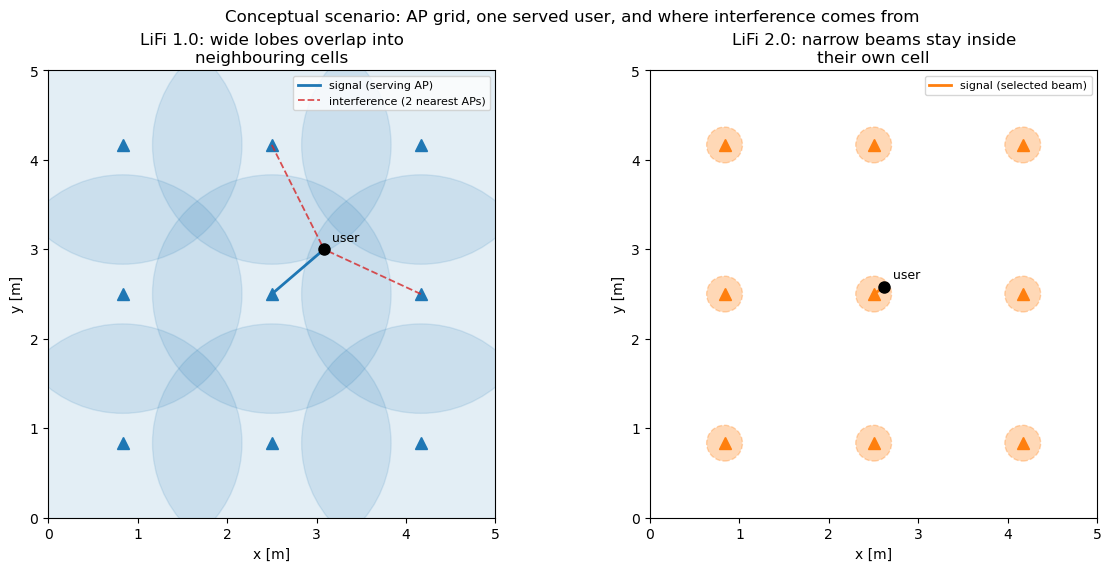

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), constrained_layout=True)

n_side = 3
cell_pitch = ROOM / n_side
ap_positions = ap_lattice(n_side)  # same helper used throughout, instead of rebuilding the lattice here
serving_idx = 4  # center AP of the 3x3 grid
serving_ap = ap_positions[serving_idx]

# LiFi 1.0: wide, overlapping Lambertian
ax = axes[0]
for x, y in ap_positions:
    ax.add_patch(plt.Circle((x, y), cell_pitch * 0.8, color="tab:blue", alpha=0.12))
    ax.plot(x, y, "^", color="tab:blue", ms=9)
user = serving_ap + np.array([cell_pitch * 0.35, cell_pitch * 0.3])
ax.plot(*user, "o", color="black", ms=8, zorder=5)
ax.annotate("user", user, textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.plot([serving_ap[0], user[0]], [serving_ap[1], user[1]], "-", color="tab:blue", lw=2, label="signal (serving AP)")

# only the 2 nearest OTHER APs are shown as interference: a wide Lambertian lobe
# does reach every AP in principle, but the 2 closest neighbours are what
# actually matter at the cell border -- the rest is comparatively negligible
others = np.array([p for i, p in enumerate(ap_positions) if i != serving_idx])
dist_to_user = np.hypot(others[:, 0] - user[0], others[:, 1] - user[1])
nearest2 = others[np.argsort(dist_to_user)[:2]]
for k, (x, y) in enumerate(nearest2):
    ax.plot([x, user[0]], [y, user[1]], "--", color="tab:red", lw=1.3, alpha=0.8,
            label="interference (2 nearest APs)" if k == 0 else None)
ax.set_xlim(0, ROOM); ax.set_ylim(0, ROOM); ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("LiFi 1.0: wide lobes overlap into\nneighbouring cells")
ax.legend(fontsize=8, loc="upper right")

# LiFi 2.0: tight, non-overlapping beam reach
ax = axes[1]
beam_reach = cell_pitch * 0.12  # illustrative: how far a single narrow beam actually reaches
for x, y in ap_positions:
    ax.add_patch(plt.Circle((x, y), beam_reach, color="tab:orange", alpha=0.3, ec="tab:orange", lw=1, ls="--"))
    ax.plot(x, y, "^", color="tab:orange", ms=9)
user2 = serving_ap + np.array([beam_reach * 0.6, beam_reach * 0.4])
ax.plot(*user2, "o", color="black", ms=8, zorder=5)
ax.annotate("user", user2, textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.plot([serving_ap[0], user2[0]], [serving_ap[1], user2[1]], "-", color="tab:orange", lw=2, label="signal (selected beam)")
ax.set_xlim(0, ROOM); ax.set_ylim(0, ROOM); ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("LiFi 2.0: narrow beams stay inside\ntheir own cell")
ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Conceptual scenario: AP grid, one served user, and where interference comes from")
plt.show()

### 2.5 Directivity

Section 4.3 of the single-cell notebook already compared these two channel shapes at each technology's realistic power. Rather than redrawing those same maps, the radial cut below reuses that comparison but adds: the AP-to-AP spacing of the lattices used in the cases that follow. That spacing is what interference actually depends on, that is, how much signal each source still has left by the time it reaches a neighbouring cell.

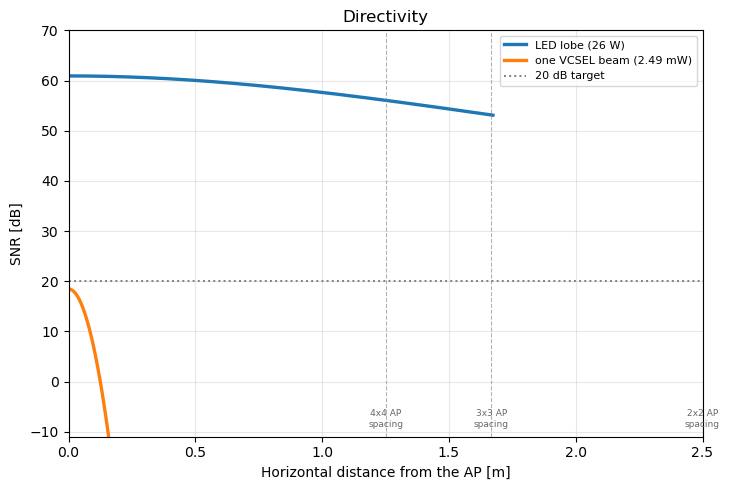

In [3]:
# same single-AP powers as the single-cell notebook's Phase 2 (LED at its
# 2x2 lighting-driven value, VCSEL at its eye-safety ceiling), but read off
# against the AP spacing of the lattices used in Cases 1-4
P2, _ = led_power(ap_lattice(2))

r = np.linspace(0, 2.5, 500)
d = np.sqrt(r**2 + dz**2); th = np.arctan2(r, dz)
h_led = np.where(th <= PSI_C, (M_LED + 1) * APD / (2 * np.pi * d**2) * np.cos(th)**M_LED * np.cos(th) * G_CONC, 0)
wz = W0 * np.sqrt(1 + (d / zR)**2)
h_v = np.where(th <= PSI_C, 2 / (np.pi * wz**2) * np.exp(-2 * r**2 / wz**2) * APD * G_CONC, 0)
with np.errstate(divide="ignore"):
    s_led = 10 * np.log10((RHO * P2 * h_led)**2 / (N0 * B_LED))
    s_v = 10 * np.log10((RHO * P_VCSEL * h_v)**2 / (N0 * B_VCSEL))

fig, ax = plt.subplots(figsize=(7.4, 5))
ax.plot(r, s_led, lw=2.4, color="tab:blue", label=f"LED lobe ({P2:.0f} W)")
ax.plot(r, s_v, lw=2.4, color="tab:orange", label=f"one VCSEL beam ({P_VCSEL * 1e3:.2f} mW)")
ax.axhline(GAMMA_TH_DB, color="gray", ls=":", lw=1.4, label=f"{GAMMA_TH_DB:.0f} dB target")

# AP spacing for the lattices used in Cases 1-4: the distance to the NEAREST
# neighbouring AP, i.e. where each technology's interference comes from
for n in (2, 3, 4):
    spacing = ROOM / n
    ax.axvline(spacing, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax.annotate(f"{n}x{n} AP\nspacing", (spacing, -9), fontsize=6.5, ha="center", color="dimgray")

ax.set_xlabel("Horizontal distance from the AP [m]")
ax.set_ylabel("SNR [dB]")
ax.set_ylim(-11, 70); ax.set_xlim(0, 2.5)
ax.set_title(f"Directivity")
ax.legend(fontsize=8, loc="upper right"); ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

At a 2x2 spacing (2.5 m), the LED's lobe is still delivering a strong signal: there is plenty left over to interfere with a neighbouring cell's user. 

At a 4x4 spacing (1.25 m) that is even more true, since the Lambertian pattern falls off slowly with distance. The VCSEL's beam, in contrast, has already dropped by tens of dB before it even reaches the loosest (2x2) spacing: there is essentially nothing left to interfere with.

That is the entire interference story for Cases 1-4 in one picture: LiFi 1.0's wide lobe reaches its neighbours no matter how tightly the APs are packed, while LiFi 2.0's beam simply runs out before it gets there.

Directivity does not create energy, it only concentrates it; so whether that is enough to reach a coverage target still depends on how much power there was to begin with, which is exactly the eye-safety constraint from Section 2.2.

### 2.6 Metrics

$R(\mathbf{u})$ is the achievable-rate lower bound from Section 2.3, evaluated at each point $\mathbf{u}$ of the receiver grid which is the same rate expression used throughout the single-cell notebook. Every metric below is derived from it.

| Metric | Definition | Source |
|---|---|---|
| Coverage | % of room points with $\gamma \ge$ 20 dB | complement of the outage metric in `[RIS-VLC]` eq. (13) |
| Mean rate | average of $R(\mathbf{u})$ over the room | `[Capacity-Bound]` |
| Cell-edge rate | 5th percentile of $R(\mathbf{u})$, the worst-served users | standard measure, not specific to either paper |
| Area spectral efficiency (ASE) | $N_{AP}\cdot\overline{R}/A_{room}$ [Mbit/s/m^2] | derived here, assuming one active user per AP |
| Energy per bit | $P_{total}/(N_{AP}\cdot\overline{R})$ [nJ/bit] | inverse of the energy-efficiency metric in `[RIS-VLC]` eq. (14) |

The last two metrics keep the comparison fair: normalizing by area and by energy means a technology can't win just by using more APs or more watts.

### 2.7 Traceability of every decision

**Taken from the papers**

| Item | Value | Source |
|---|---|---|
| LED half-power semiangle -> Lambertian order | 80 deg -> $m$ = 0.40 | `[RIS-VLC]` Table III, eq. (1) |
| PD area $A_{PD}$ / responsivity $\rho$ | 1 cm^2 / 1 A/W | `[RIS-VLC]` Table III and `[VCSEL-Precoding]` Table I (they agree) |
| Receiver FoV $\Psi_c$ | 40 deg | `[RIS-VLC]` Table III (30/40/50 deg) |
| Concentrator $n$ -> gain $G$ | 1.5 -> 5.45 | `[VCSEL-Precoding]` eq. (8) |
| Bandwidths | 20 MHz / 2 GHz | `[RIS-VLC]` Table III / `[VCSEL-Precoding]` Table I |
| Noise PSD $N_0$ | 2.5e-20 W/Hz | `[RIS-VLC]` Table III |
| Luminous efficacy / lighting limits | 280 lm/W; 500 lux avg (enforced), 800 lux max (checked) | `[RIS-VLC]` Table III (C5, C8), EN 12464-1 |
| VCSEL wavelength / array pitch | 950 nm / 10 um (emitters effectively co-located) | `[VCSEL-Precoding]` Table I |
| Beam waist $w_0$ | 5 um | `[Eye-Safety]` Figs. 7, 9, 13, 16-18 |
| Eye-safe power per emitter | 2.49 mW, ported from the single-cell notebook's `eye_safe_ptx()` | `[Eye-Safety]` Algorithm 1 + eq. (36) at $w_0=5\ \mu m$; corroborated to the same order of magnitude by `[VCSEL-70Gbps]`'s ~5 mW measured operating power (Fig. 1), kept only as a cross-check |
| SINR threshold | 20 dB | inside the [10, 50] dB range of `[RIS-VLC]` Table III, which spans 2-PAM to 256-PAM at BER 1e-6 |
| Lambertian channel / SNR / outage / rate / energy efficiency / illuminance | eqs. (1), (12), (13), (14), (24)-(26) | `[RIS-VLC]` |
| Gaussian beam / concentrator / SINR / rate / cooperative broadcast | eqs. (2)-(8), (11), (12), Sec. II-B | `[VCSEL-Precoding]` |
| IM/DD rate bound | -- | `[Capacity-Bound]` |
| Eye-safety source classification ($\alpha_{min}$, $\alpha_{max}$, $C_6$) | 1.5 / 100 mrad | `[Eye-Safety]` Sec. III-C, Table 4 |
| 2x2 LED lattice / dense VCSEL grids | -- | `[RIS-VLC]` Sec. V / `[VCSEL-Precoding]` Sec. V |

**Own decisions/assumptions**

| Decision | Why | Effect |
|---|---|---|
| Room 5x5x3 m | keeps continuity with the single-cell notebook; sits between the papers' own rooms (4x4x3 and 3x3x5) | changes absolute numbers, not mechanisms |
| N x N AP lattice as the deployment variable | generalizes the 2x2 benchmark used in `[RIS-VLC]` | gives the natural design space for densification |
| Best-server (RSS) association | neither paper specifies one (they use TDMA or full cooperation instead) | a different rule would mostly move the cell borders |
| VCSEL AP modelled as a beam array with beam selection | a simplified stand-in for the precoding of `[VCSEL-Precoding]` | conservative, so the LiFi 2.0 results here are a lower bound -- and, combined with the honest eye-safe power, the reason single-beam coverage caps out at 0% in Section 3 |
| VCSEL power ported from the single-cell notebook rather than re-derived here | keeps both notebooks' "justified value" for the same parameter identical, not just similar | this is what makes the 0%-coverage finding in Section 3 a standards-driven result rather than a choice made to fit a narrative |
| LED illuminance held to a 500-800 lux compliant band, not a single fixed point | 500 lux is `[RIS-VLC]`/EN 12464-1's floor; 800 lux is its own ceiling, already checked as the "Lighting" column in Section 3 -- itself an eye-safety-adjacent, glare-avoidance limit, so both technologies have a standards-mandated power ceiling, not just the VCSEL | keeps the LED side honest about its own limit, instead of treating 500 lux as an arbitrary target |
| APs get independent eye-safety budgets; emitters inside one AP share a single budget | follows from the subtense-based classification in `[Eye-Safety]`, though no explicit multi-AP rule is given there | conservative, since the $C_6$ relaxation would allow more array power |
| Local cooperation cluster = APs within 3 dB of the best | a simple, scalable clustering rule; the papers define none | the global-cooperation case still bounds any other choice |
| One active user per AP | the simplest possible scheduling assumption | multi-user scheduling within a cell is not modelled |

---

## 3. Case 1: equal coverage target

Coverage target: 95% of the room above 20 dB SINR. The question here is the first and simplest one to ask: what is the minimum deployment each technology needs to reach it?

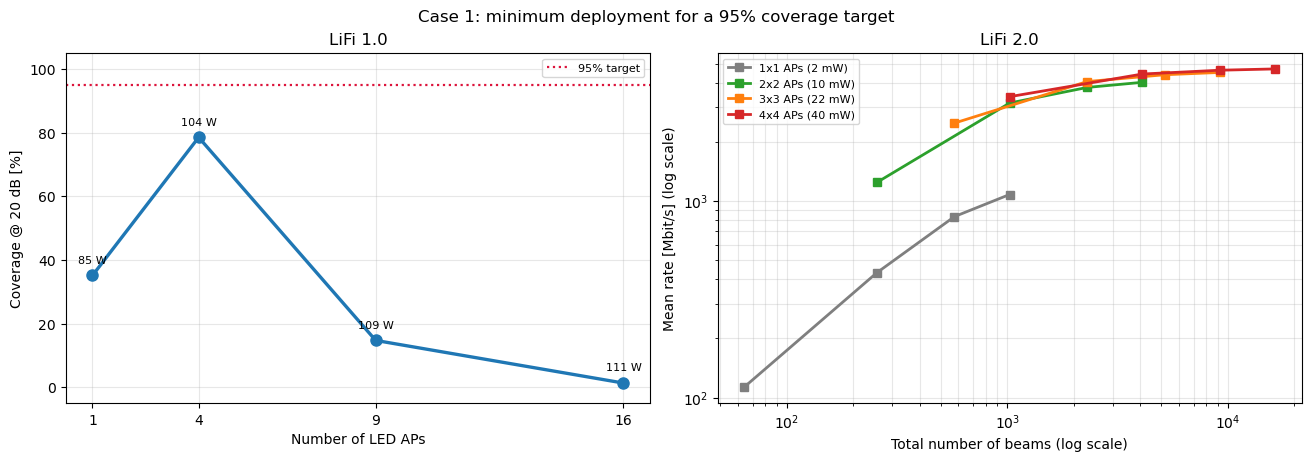

LiFi 1.0: target NOT met by any deployment (best: 2x2 -> 78.5% with 103.9 W)
Lighting (800 lux peak) compliance by density: 1: peak 1320 lux > 800, 4: OK, 9: OK, 16: OK

LiFi 2.0: coverage @ 20 dB = 0.0% at every deployment tried (64 to 16384 beams): a single beam's own peak SNR never reaches the threshold (Section 2.2), so no beam count can meet the 95% target either.
Mean rate still climbs steeply with beam count: 113.0 to 4695.8 Mbit/s across the sweep, at 2.5 to 39.9 mW total.


In [4]:
led_rows = []
for n in [1, 2, 3, 4]:
    s, Pt, nc, Ev = evaluate_led(n)
    r, _ = metrics(s, B_LED, Pt, nc, f"LiFi 1.0 -- {n}x{n} LED APs")
    r["Lighting"] = "OK" if Ev.max() <= E_MAX else f"peak {Ev.max():.0f} lux > 800"
    r["95% met?"] = "YES" if r["Coverage [%]"] >= COV_TARGET else "no"
    led_rows.append(r)
led_df = pd.DataFrame(led_rows)

v_rows = []
for n in [1, 2, 3, 4]:
    for m in [8, 16, 24, 32]:
        s, Pt, nc = evaluate_vcsel(n, m)
        r, _ = metrics(s, B_VCSEL, Pt, nc, f"LiFi 2.0 -- {n}x{n} APs x {m*m} beams",
                       **{"Beams/AP": m*m, "Total beams": nc*m*m})
        r["95% met?"] = "YES" if r["Coverage [%]"] >= COV_TARGET else "no"
        v_rows.append(r)
vdf = pd.DataFrame(v_rows)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
# LiFi 1.0: coverage vs number of APs
ax[0].plot(led_df.APs, led_df["Coverage [%]"], "o-", color="tab:blue", lw=2.4, ms=8)
ax[0].axhline(COV_TARGET, color="crimson", ls=":", lw=1.6, label="95% target")
for _, r in led_df.iterrows():
    ax[0].annotate(f"{r['P total [W]']:.0f} W", (r.APs, r["Coverage [%]"]),
                   textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)
ax[0].set_xlabel("Number of LED APs"); ax[0].set_ylabel("Coverage @ 20 dB [%]")
ax[0].set_xticks([1, 4, 9, 16]); ax[0].set_ylim(-5, 105)
ax[0].set_title("LiFi 1.0")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# LiFi 2.0
for n, col in zip([1, 2, 3, 4], ["tab:gray", "tab:green", "tab:orange", "tab:red"]):
    sub = vdf[vdf.APs == n*n]
    ax[1].plot(sub["Total beams"], sub["Mean rate [Mbit/s]"], "s-", color=col, lw=2, ms=6,
               label=f"{n}x{n} APs ({n*n*P_VCSEL*1e3:.0f} mW)")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("Total number of beams (log scale)")
ax[1].set_ylabel("Mean rate [Mbit/s] (log scale)")
ax[1].set_title("LiFi 2.0")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which="both")
fig.suptitle("Case 1: minimum deployment for a 95% coverage target")
plt.show()

print(f"LiFi 1.0: target NOT met by any deployment (best: 2x2 -> {led_df['Coverage [%]'].max():.1f}% "
      f"with {led_df.loc[led_df['Coverage [%]'].idxmax(), 'P total [W]']:.1f} W)")
print("Lighting (800 lux peak) compliance by density: "
      + ", ".join(f"{r.APs}: {r.Lighting}" for r in led_df.itertuples()))
print(f"\nLiFi 2.0: coverage @ {GAMMA_TH_DB:.0f} dB = {vdf['Coverage [%]'].max():.1f}% at every deployment tried "
      f"({vdf['Total beams'].min()} to {vdf['Total beams'].max()} beams): a single beam's own peak SNR never reaches the threshold "
      f"(Section 2.2), so no beam count can meet the 95% target either.")
print(f"Mean rate still climbs steeply with beam count: {vdf['Mean rate [Mbit/s]'].min():.1f} to "
      f"{vdf['Mean rate [Mbit/s]'].max():.1f} Mbit/s across the sweep, at "
      f"{vdf['P total [W]'].min() * 1e3:.1f} to {vdf['P total [W]'].max() * 1e3:.1f} mW total.")

In [5]:
vdf[["Deployment", "APs", "Beams/AP", "Total beams", "P total [W]",
     "Mean rate [Mbit/s]", "Energy/bit [nJ]"]]

,Deployment,APs,Beams/AP,Total beams,P total [W],Mean rate [Mbit/s],Energy/bit [nJ]
0,LiFi 2.0 -- 1x1 APs x 64 beams,1,64,64,0.0025,113.0,0.0221
1,LiFi 2.0 -- 1x1 APs x 256 beams,1,256,256,0.0025,431.7,0.0058
2,LiFi 2.0 -- 1x1 APs x 576 beams,1,576,576,0.0025,833.2,0.0030
3,LiFi 2.0 -- 1x1 APs x 1024 beams,1,1024,1024,0.0025,1079.0,0.0023
4,LiFi 2.0 -- 2x2 APs x 64 beams,4,64,256,0.0100,1242.5,0.0020
5,LiFi 2.0 -- 2x2 APs x 256 beams,4,256,1024,0.0100,3148.9,0.0008
6,LiFi 2.0 -- 2x2 APs x 576 beams,4,576,2304,0.0100,3781.0,0.0007
7,LiFi 2.0 -- 2x2 APs x 1024 beams,4,1024,4096,0.0100,4013.9,0.0006
8,LiFi 2.0 -- 3x3 APs x 64 beams,9,64,576,0.0224,2490.9,0.0010
9,LiFi 2.0 -- 3x3 APs x 256 beams,9,256,2304,0.0224,4050.0,0.0006


The two panels use different axes on purpose: the left one plots what actually varies for LiFi 1.0 (coverage, against the number of LED APs); the right one plots what actually varies for LiFi 2.0 (mean rate, against the total beam count). Coverage is not plotted for LiFi 2.0 here because it stays at 0% regardless of beam count, so it would not be an informative axis. The one quantity that is genuinely comparable between the two panels, transmit power, is annotated directly on each curve/legend entry.

* **LiFi 1.0 never reaches the 95% target, and densifying only makes it worse:** coverage goes 78.5% (2x2) -> 14.7% (3x3) -> 1.3% (4x4). Once the AP spacing drops below the FoV footprint (the 1.68 m ground radius a receiver's field of view admits light from), every user starts seeing several LEDs of similar strength, and the SINR collapses at the cell borders. More power cannot fix this, since signal and interference scale together.

* **LiFi 2.0 never reaches it either, but for a completely different reason: coverage @ 20 dB stays at exactly 0%, at every deployment tried.** A single beam's own best-case SNR (Section 2.2) already sits below the 20 dB bar, and beam selection only ever activates one beam at a time so packing in more, more closely-spaced beams shrinks the distance to the nearest one without ever raising that ceiling. This is an architectural limit of the eye-safe power and single-beam-selection combination.

* **Coverage and rate are decoupled for LiFi 2.0 in a way they aren't for LiFi 1.0.** More beams still buys real throughput, but mean rate keeps climbing with beam count at a few to several tens of milliwatts total power, just not "coverage" as defined by this particular 20 dB bar (Section 2.7).

**Sensitivity to the coverage threshold.** Every coverage number in this notebook uses $\gamma_{th}=20$ dB. Since this choice matters most for LiFi 2.0's 0% result. 

The plot below sweeps $\gamma_{th}$ for the same representative 3x3 deployment used in Case 2 (LED 3x3, VCSEL 3x3 x 256 beams/AP, non-cooperative).

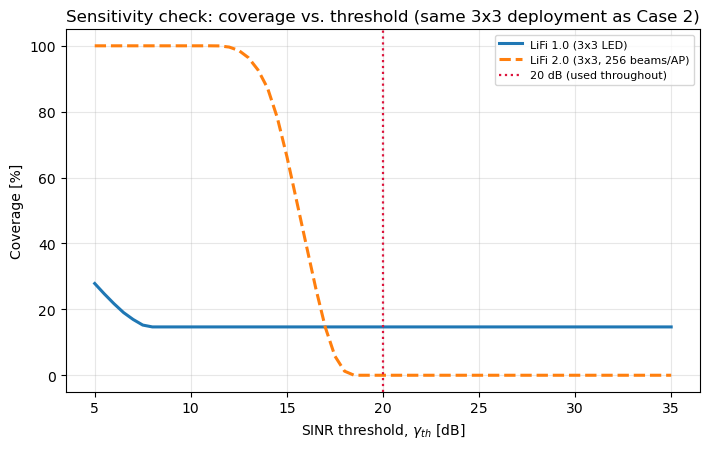

LiFi 1.0 coverage settles at 14.7% by about 8-10 dB and stays flat there up to 30+ dB (it only moves at the very low end of the sweep).
LiFi 2.0 coverage crosses its own 50% point around 16 dB, and reaches 0% by about 19 dB - just past a single beam's own peak SINR (18.4 dB, Section 2.2).


In [6]:
# sensitivity check: sweep gamma_th instead of fixing it at 20 dB, for the same
# representative 3x3 deployment used in Case 2 (non-cooperative)
th_sweep_dB = np.linspace(5, 35, 61)
s_led_ref, _, _, _ = evaluate_led(3)
s_vcsel_ref, _, _ = evaluate_vcsel(3, 16)
cov_led_th = [100 * np.mean(s_led_ref >= 10**(t / 10)) for t in th_sweep_dB]
cov_vcsel_th = [100 * np.mean(s_vcsel_ref >= 10**(t / 10)) for t in th_sweep_dB]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(th_sweep_dB, cov_led_th, color="tab:blue", lw=2.2, label="LiFi 1.0 (3x3 LED)")
ax.plot(th_sweep_dB, cov_vcsel_th, color="tab:orange", lw=2.2, ls="--", label="LiFi 2.0 (3x3, 256 beams/AP)")
ax.axvline(GAMMA_TH_DB, color="crimson", ls=":", lw=1.6, label=f"{GAMMA_TH_DB:.0f} dB (used throughout)")
ax.set_xlabel(r"SINR threshold, $\gamma_{th}$ [dB]")
ax.set_ylabel("Coverage [%]")
ax.set_title("Sensitivity check: coverage vs. threshold (same 3x3 deployment as Case 2)")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

th_50pct = th_sweep_dB[np.argmin(np.abs(np.array(cov_vcsel_th) - 50))]
led_plateau = cov_led_th[np.argmin(np.abs(th_sweep_dB - GAMMA_TH_DB))]
print(f"LiFi 1.0 coverage settles at {led_plateau:.1f}% by about 8-10 dB and stays flat there up to 30+ dB "
      f"(it only moves at the very low end of the sweep).")
print(f"LiFi 2.0 coverage crosses its own 50% point around {th_50pct:.0f} dB, and reaches 0% by about 19 dB - "
      f"just past a single beam's own peak SINR ({peak_snr_dB:.1f} dB, Section 2.2).")

LiFi 1.0's coverage barely moves across this range: inside its FoV-limited area it has SINR headroom to spare, so only much harder thresholds would start eating into it (the same pattern the single-cell notebook found in Phase 1). LiFi 2.0's coverage instead falls sharply, from effectively 100% to 0% between about 12 and 19 dB, landing at exactly 0% right where 20 dB sits.

That steep transition is the real reason for the 0% result: it sits just past the point where a single beam's own peak SINR runs out of headroom (Section 2.2). A meaningfully lower threshold (below roughly 12 dB) would restore full coverage under beam selection alone, but that would mean accepting a much lower link quality than the 20 dB bar used throughout this notebook and the single-cell one, not a different reading of the same result.

## 4. Case 2: equal infrastructure

Case 1 sized each technology to its own target, so the two never used the same number of APs at the same time. This case removes that degree of freedom: it fixes the same AP positions for both technologies, so any difference in the results comes only from the transmitter itself, not from a different deployment size. Equal infrastructure does not mean equal power, though, since each AP still runs at its own Section 2 operating point.

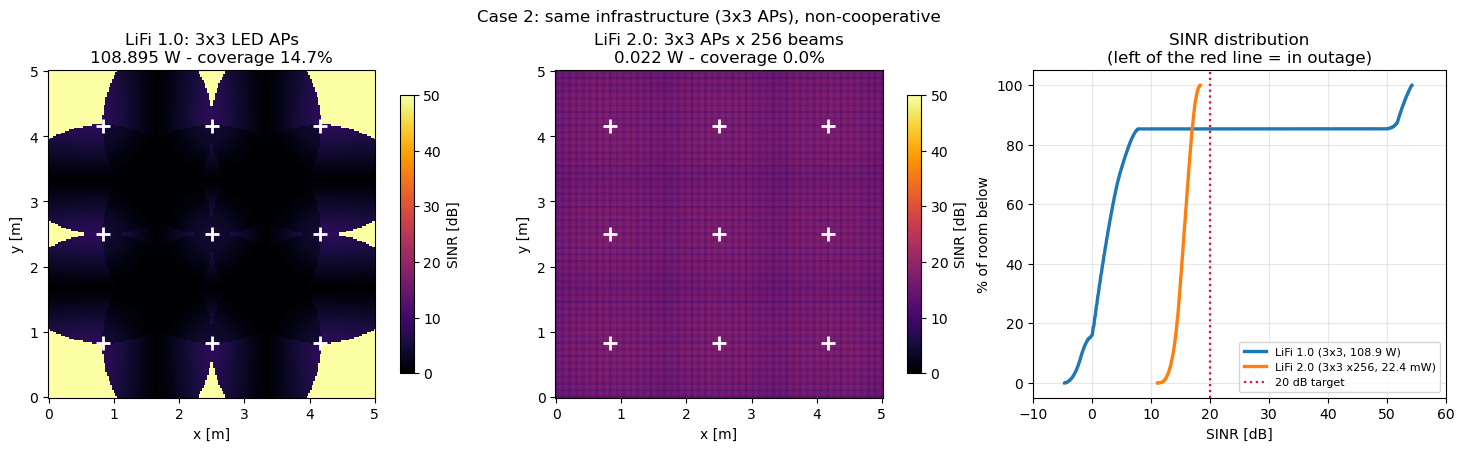

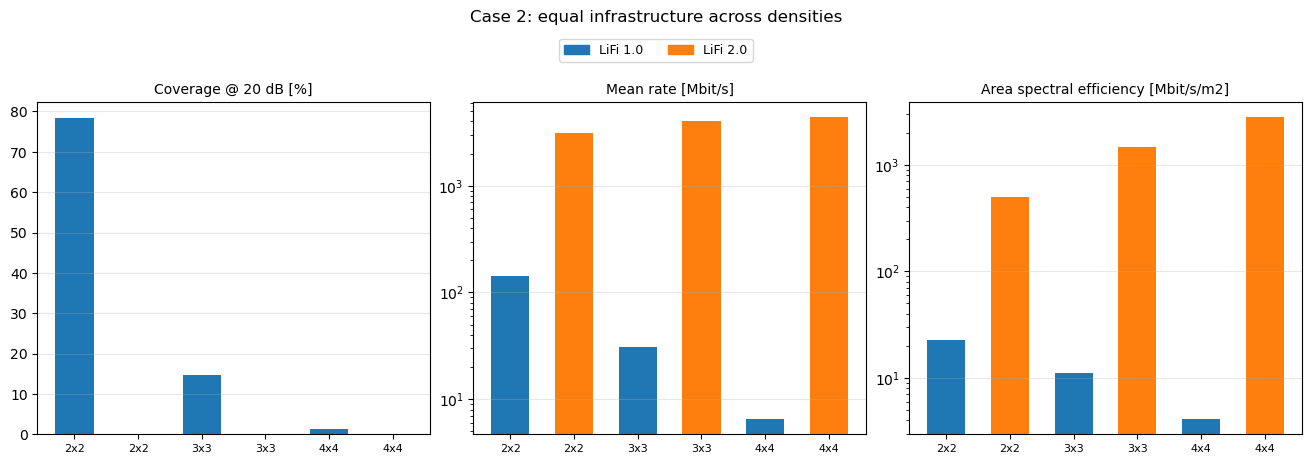

In [7]:
iso = []
for n in [2, 3, 4]:
    s, P, nc, _ = evaluate_led(n)
    r, _ = metrics(s, B_LED, P, nc, f"{n}x{n} - LiFi 1.0 (LED)"); iso.append(r)
    s, P, nc = evaluate_vcsel(n, 16)
    r, _ = metrics(s, B_VCSEL, P, nc, f"{n}x{n} - LiFi 2.0 (256 beams/AP)"); iso.append(r)
iso_df = pd.DataFrame(iso)

s_led, P_led, _, _ = evaluate_led(3)
s_v, P_v, _ = evaluate_vcsel(3, 16)
cm = plt.cm.inferno.copy(); cm.set_bad("black")
fig = plt.figure(figsize=(15, 4.4), constrained_layout=True)
gs = fig.add_gridspec(1, 3)
for k, (S, ttl, P, cov) in enumerate([
        (s_led, "LiFi 1.0: 3x3 LED APs", P_led, 100*np.mean(s_led >= GAMMA_TH)),
        (s_v, "LiFi 2.0: 3x3 APs x 256 beams", P_v, 100*np.mean(s_v >= GAMMA_TH))]):
    ax = fig.add_subplot(gs[0, k])
    dB = np.where(S > 0, 10*np.log10(np.where(S > 0, S, 1)), np.nan)
    im = ax.pcolormesh(X, Y, dB, shading="auto", cmap=cm, vmin=0, vmax=50)
    ax.plot(ap_lattice(3)[:, 0], ap_lattice(3)[:, 1], "w+", ms=10, mew=2)
    ax.set_title(f"{ttl}\n{P:.3f} W - coverage {cov:.1f}%")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, label="SINR [dB]", shrink=0.85)

# CDF panel
ax = fig.add_subplot(gs[0, 2])
for S, lb, c in [(s_led, f"LiFi 1.0 (3x3, {P_led:.1f} W)", "tab:blue"),
                 (s_v, f"LiFi 2.0 (3x3 x256, {P_v*1e3:.1f} mW)", "tab:orange")]:
    d = np.sort(10*np.log10(np.maximum(S.ravel(), 1e-12)))
    ax.plot(d, np.linspace(0, 100, d.size), lw=2.4, color=c, label=lb)
ax.axvline(GAMMA_TH_DB, color="crimson", ls=":", lw=1.6, label="20 dB target")
ax.set_xlim(-10, 60); ax.set_xlabel("SINR [dB]"); ax.set_ylabel("% of room below")
ax.set_title("SINR distribution\n(left of the red line = in outage)")
ax.legend(fontsize=8); ax.grid(alpha=.3)
fig.suptitle("Case 2: same infrastructure (3x3 APs), non-cooperative")
plt.show()

# grouped bar chart across all 3 densities, same visual language as Section 8
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
colors = iso_df["Deployment"].str.contains("1.0").map({True: "tab:blue", False: "tab:orange"})
x = np.arange(len(iso_df))
for ax, (col, ttl, logy) in zip(axes, [("Coverage [%]", "Coverage @ 20 dB [%]", False),
                                        ("Mean rate [Mbit/s]", "Mean rate [Mbit/s]", True),
                                        ("ASE [Mbit/s/m2]", "Area spectral efficiency [Mbit/s/m2]", True)]):
    ax.bar(x, iso_df[col], color=colors, width=0.6)
    if logy:
        ax.set_yscale("log")
    ax.set_xticks(x); ax.set_xticklabels([d.split(" - ")[0] for d in iso_df.Deployment], fontsize=8)
    ax.set_title(ttl, fontsize=10); ax.grid(alpha=.3, axis="y")
fig.legend(handles=[Patch(color="tab:blue", label="LiFi 1.0"), Patch(color="tab:orange", label="LiFi 2.0")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.12), fontsize=9)
fig.suptitle("Case 2: equal infrastructure across densities", y=1.18)
plt.show()

At 3x3 APs, LiFi 2.0 delivers 4.05 Gbit/s mean rate at 22.4 mW total, against LiFi 1.0's 30.9 Mbit/s at 108.9 W, but its coverage @ 20 dB is 0%, not a competing number to the LED's 14.7%. The maps and CDF show why, and it's two different failure modes.

* **The LED map is bright inside each cell and pitch-black along every border**: interference-limited. The CDF confirms it: a large fraction of the room sits far below the target.

* **The VCSEL map is a fine texture of bright-ish spots, all of them still below the 20 dB line.** The CDF makes this exact: the whole orange curve sits to the left of the red threshold, since even a beam's own axis tops out at 18.4 dB (Section 2.2); a headroom problem, not a coverage-gap problem, and more beams cannot fix a headroom problem.

The bar chart adds the density trend: LiFi 1.0's coverage and ASE both get worse as APs are added (interference grows faster than signal), while LiFi 2.0's mean rate and ASE climb steadily even though its coverage number never moves off zero.

## 5. Case 3: cross-equivalence

Case 2 compared both technologies at the same deployment size and found very different outcomes. This case asks the question the other way around: instead of fixing the deployment and comparing outcomes, fix one technology's outcome as a target and ask what the other would need to match it (in both directions).

**Direction A's reference is LiFi 1.0's own 2x2 deployment**: the size its lighting requirement already forces it to, independent of any communications target. Does any LiFi 2.0 configuration match its mean rate and cell-edge rate? (Coverage is checked separately: Section 3 already showed it is architecturally 0% for LiFi 2.0 at any beam count, so it cannot be a "matched" metric here)

**Direction B's reference is LiFi 2.0's Case 2 deployment (3x3 APs, 256 beams/AP)**: a representative, already-analyzed configuration, used since LiFi 2.0 has no "cheapest 100%-coverage" deployment to anchor to instead. Does any LiFi 1.0 deployment match its mean rate and cell-edge rate?

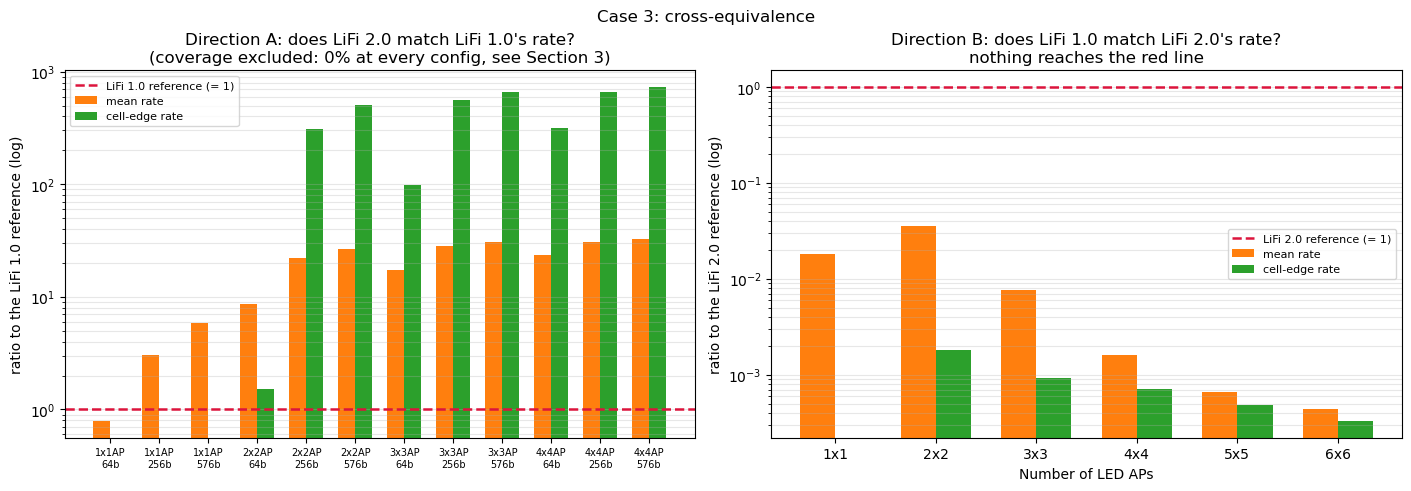

LiFi 2.0 configs matching BOTH rate metrics of the LED 2x2 reference:
   cheapest: 2x2 APs x 64 beams  ->  256 beams, 10.00 mW (10388x less optical power than the LED)
   coverage @ 20 dB, however, is 0% for every one of these -- never matched (Section 3)

Reverse direction: best LED mean rate = 143.2 Mbit/s vs 4050 Mbit/s required -> short by 28x, set by BANDWIDTH (20 MHz vs 2 GHz)
Cell-edge rate falls short by an even larger margin: best LED cell-edge rate = 6.0 Mbit/s vs 3335 Mbit/s required.


In [8]:
# Direction A: LiFi 1.0 reference = 2x2 LEDs (the deployment its lighting requires)
s_ref, P_ref, nc_ref, _ = evaluate_led(2)
ref, _ = metrics(s_ref, B_LED, P_ref, nc_ref, "REFERENCE")

rowsA = []
for n in [1, 2, 3, 4]:
    for m in [8, 16, 24]:
        s, Pt, nc = evaluate_vcsel(n, m)
        r, _ = metrics(s, B_VCSEL, Pt, nc, f"{n}x{n} APs x {m*m} beams", **{"Total beams": nc*m*m})
        r["rate"] = r["Mean rate [Mbit/s]"] / ref["Mean rate [Mbit/s]"]
        r["edge"] = r["Cell-edge rate [Mbit/s]"] / max(ref["Cell-edge rate [Mbit/s]"], 1e-9)
        r["BOTH?"] = "*** YES ***" if min(r["rate"], r["edge"]) >= 1 else ""
        rowsA.append(r)
dfA = pd.DataFrame(rowsA)

# Direction B: LiFi 2.0 reference = the 3x3 x256-beam deployment from Case 2
s_v, P_v, nc_v = evaluate_vcsel(3, 16)
refv, _ = metrics(s_v, B_VCSEL, P_v, nc_v, "REF")
ns = [1, 2, 3, 4, 5, 6]
rowsB = []
for n in ns:
    s, Pt, nc, _ = evaluate_led(n)
    r, _ = metrics(s, B_LED, Pt, nc, f"{n}x{n} LED APs")
    r["rate"] = r["Mean rate [Mbit/s]"] / refv["Mean rate [Mbit/s]"]
    r["edge"] = r["Cell-edge rate [Mbit/s]"] / max(refv["Cell-edge rate [Mbit/s]"], 1e-9)
    rowsB.append(r)
dfB = pd.DataFrame(rowsB)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
x = np.arange(len(dfA)); w = 0.35
ax[0].bar(x - w/2, dfA["rate"], w, label="mean rate", color="tab:orange")
ax[0].bar(x + w/2, dfA["edge"], w, label="cell-edge rate", color="tab:green")
ax[0].axhline(1, color="crimson", ls="--", lw=1.8, label="LiFi 1.0 reference (= 1)")
ax[0].set_yscale("log"); ax[0].set_xticks(x)
ax[0].set_xticklabels([d.replace(" APs x ", "AP\n").replace(" beams", "b") for d in dfA.Deployment],
                      rotation=0, fontsize=7)
ax[0].set_ylabel("ratio to the LiFi 1.0 reference (log)")
ax[0].set_title("Direction A: does LiFi 2.0 match LiFi 1.0's rate?\n"
                "(coverage excluded: 0% at every config, see Section 3)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, axis="y", which="both")

# same ratio-to-reference bar format as Direction A, both metrics, both directions
wB = 0.35
ax[1].bar(np.arange(len(dfB)) - wB / 2, dfB["rate"], wB, color="tab:orange", label="mean rate")
ax[1].bar(np.arange(len(dfB)) + wB / 2, dfB["edge"], wB, color="tab:green", label="cell-edge rate")
ax[1].axhline(1, color="crimson", ls="--", lw=1.8, label="LiFi 2.0 reference (= 1)")
ax[1].set_yscale("log"); ax[1].set_xticks(np.arange(len(dfB)))
ax[1].set_xticklabels([f"{n}x{n}" for n in ns])
ax[1].set_xlabel("Number of LED APs"); ax[1].set_ylabel("ratio to the LiFi 2.0 reference (log)")
ax[1].set_title("Direction B: does LiFi 1.0 match LiFi 2.0's rate?\nnothing reaches the red line")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, axis="y", which="both")
fig.suptitle("Case 3: cross-equivalence")
plt.show()

best = dfA[dfA["BOTH?"] != ""].sort_values("Total beams")
print("LiFi 2.0 configs matching BOTH rate metrics of the LED 2x2 reference:")
if best.empty:
    print("  none in this sweep")
else:
    b = best.iloc[0]
    print(f"   cheapest: {b['Deployment']}  ->  {b['Total beams']} beams, {b['P total [W]']*1000:.2f} mW "
          f"({P_ref/b['P total [W]']:.0f}x less optical power than the LED)")
print(f"   coverage @ {GAMMA_TH_DB:.0f} dB, however, is 0% for every one of these -- never matched (Section 3)")
print(f"\nReverse direction: best LED mean rate = {dfB['Mean rate [Mbit/s]'].max():.1f} Mbit/s vs "
      f"{refv['Mean rate [Mbit/s]']:.0f} Mbit/s required -> short by "
      f"{refv['Mean rate [Mbit/s]']/dfB['Mean rate [Mbit/s]'].max():.0f}x, set by BANDWIDTH (20 MHz vs 2 GHz)")
print(f"Cell-edge rate falls short by an even larger margin: best LED cell-edge rate = "
      f"{dfB['Cell-edge rate [Mbit/s]'].max():.1f} Mbit/s vs {refv['Cell-edge rate [Mbit/s]']:.0f} Mbit/s required.")

**Direction A.** Rate and cell-edge rate are both matched at trivial cost: 4 APs (2x2) with 64 beams each, 256 beams total, already beat the LED reference on both, at 10 mW against the LED's 104 W. But coverage @ 20 dB is 0% for every one of these configurations, and stays that way regardless of beam count (Section 3): rate and coverage are different axes for LiFi 2.0, and only one of them can be bought with more beams.

**Direction B.** No LED deployment comes close to LiFi 2.0's mean rate or cell-edge rate: since $R \propto B$, the 20 MHz vs 2 GHz gap is a bandwidth ceiling no number of LEDs or added watts can close.

So the equivalence is still asymmetric, but not for the reason it first appears: LiFi 2.0 trivially out-throughputs LiFi 1.0 at a fraction of the power, while LiFi 1.0 can never out-throughput LiFi 2.0, because bandwidth is not something a deployment choice can change. What LiFi 2.0 *cannot* do is match LiFi 1.0's specific coverage number, not because it needs a bigger deployment, but because a single selected beam's own eye-safe power sits below the bar to begin with.

## 6. Case 4: scalability and densification

This case asks whether adding infrastructure actually adds capacity, which is the question that could decide whether either technology is viable for a 6G-style ultra-dense deployment.

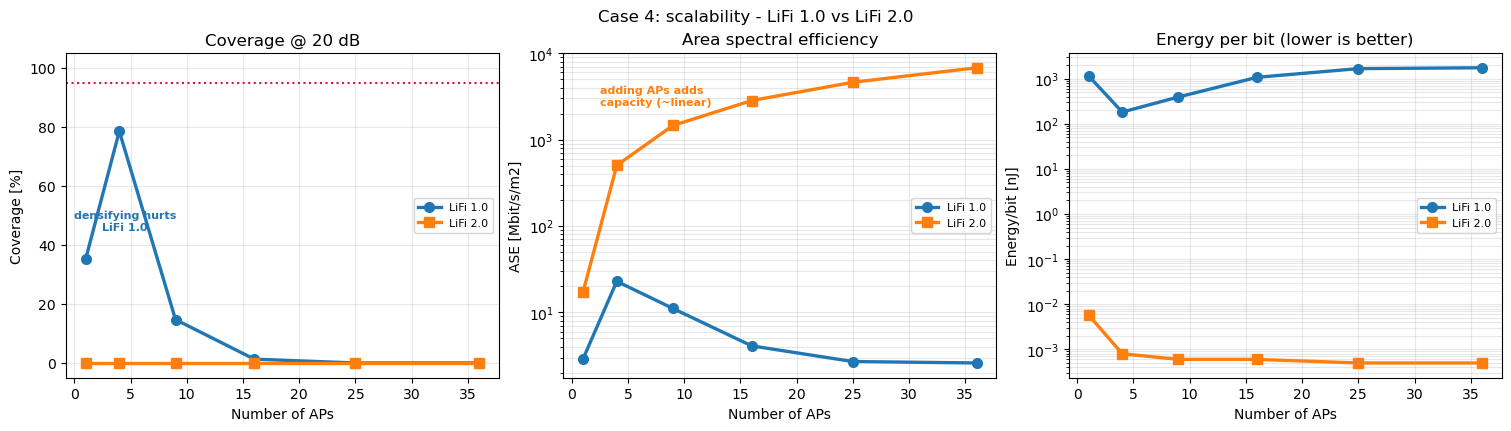

,Deployment,APs,P total [W],Coverage [%],Mean rate [Mbit/s],ASE [Mbit/s/m2],Energy/bit [nJ]
0,LiFi 1.0 -- 1x1,1,84.8819,35.1,73.7,2.9,1151.3957
1,LiFi 1.0 -- 2x2,4,103.8835,78.5,143.2,22.9,181.3559
2,LiFi 1.0 -- 3x3,9,108.8946,14.7,30.9,11.1,391.2410
3,LiFi 1.0 -- 4x4,16,110.5736,1.3,6.5,4.1,1068.2005
4,LiFi 1.0 -- 5x5,25,111.3198,0.0,2.7,2.7,1662.1118
5,LiFi 1.0 -- 6x6,36,111.7174,0.0,1.8,2.6,1737.1498
6,LiFi 2.0 -- 1x1 (256 beams/AP),1,0.0025,0.0,431.7,17.3,0.0058
7,LiFi 2.0 -- 2x2 (256 beams/AP),4,0.0100,0.0,3148.9,503.8,0.0008
8,LiFi 2.0 -- 3x3 (256 beams/AP),9,0.0224,0.0,4050.0,1458.0,0.0006
9,LiFi 2.0 -- 4x4 (256 beams/AP),16,0.0399,0.0,4423.4,2831.0,0.0006


In [9]:
dens = []
for n in [1, 2, 3, 4, 5, 6]:
    s, Pt, nc, Ev = evaluate_led(n)
    r, _ = metrics(s, B_LED, Pt, nc, f"LiFi 1.0 -- {n}x{n}")
    r["Lighting"] = "OK" if Ev.max() <= E_MAX else f"peak {Ev.max():.0f} lux > 800"
    dens.append(r)
for n in [1, 2, 3, 4, 5, 6]:
    s, Pt, nc = evaluate_vcsel(n, 16)
    r, _ = metrics(s, B_VCSEL, Pt, nc, f"LiFi 2.0 -- {n}x{n} (256 beams/AP)"); dens.append(r)
ddf = pd.DataFrame(dens)
L = ddf[ddf.Deployment.str.contains("1.0")]; V = ddf[ddf.Deployment.str.contains("2.0")]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for a, key, ttl, logy in [(ax[0], "Coverage [%]", "Coverage @ 20 dB", False),
                          (ax[1], "ASE [Mbit/s/m2]", "Area spectral efficiency", True),
                          (ax[2], "Energy/bit [nJ]", "Energy per bit (lower is better)", True)]:
    plot = a.semilogy if logy else a.plot
    plot(L.APs, L[key], "o-", color="tab:blue", lw=2.4, ms=7, label="LiFi 1.0")
    plot(V.APs, V[key], "s-", color="tab:orange", lw=2.4, ms=7, label="LiFi 2.0")
    a.set_xlabel("Number of APs"); a.set_ylabel(key); a.set_title(ttl)
    a.legend(fontsize=8); a.grid(alpha=.3, which="both")
ax[0].axhline(COV_TARGET, color="crimson", ls=":", lw=1.5); ax[0].set_ylim(-5, 105)
ax[0].annotate("densifying hurts\nLiFi 1.0", (4.5, 45), fontsize=8, color="tab:blue",
               ha="center", weight="bold")
ax[1].annotate("adding APs adds\ncapacity (~linear)", (2.5, 2500), fontsize=8,
               color="tab:orange", weight="bold")
fig.suptitle("Case 4: scalability - LiFi 1.0 vs LiFi 2.0")
plt.show()

ddf[["Deployment", "APs", "P total [W]", "Coverage [%]", "Mean rate [Mbit/s]",
     "ASE [Mbit/s/m2]", "Energy/bit [nJ]"]]

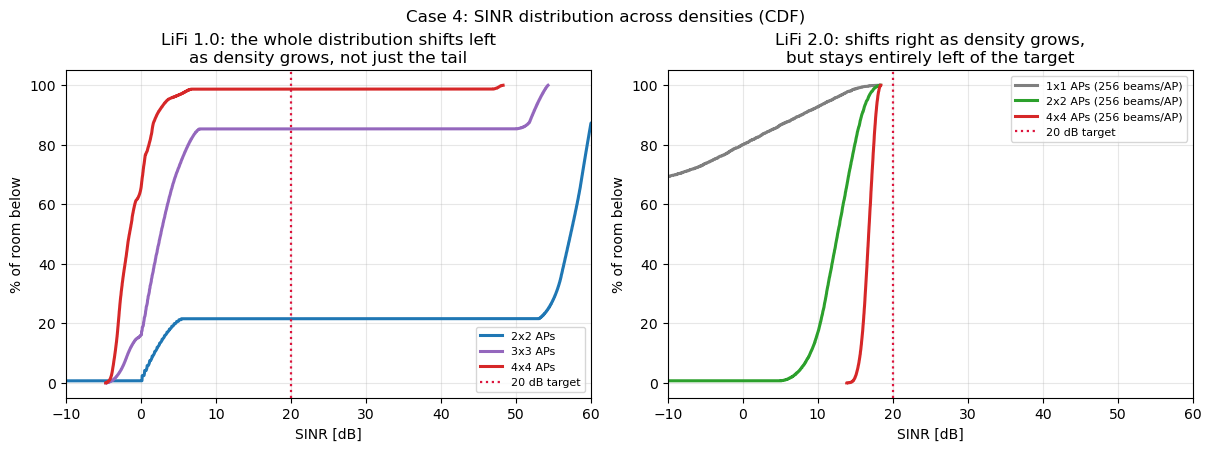

In [10]:
# same idea as the Case 2 CDF, now across densities: does the whole SINR distribution
# shift with N, or just the single coverage number?
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)

for n, c in zip([2, 3, 4], ["tab:blue", "tab:purple", "tab:red"]):
    s, _, _, _ = evaluate_led(n)
    d = np.sort(10 * np.log10(np.maximum(s.ravel(), 1e-12)))
    ax[0].plot(d, np.linspace(0, 100, d.size), lw=2.2, color=c, label=f"{n}x{n} APs")
ax[0].axvline(GAMMA_TH_DB, color="crimson", ls=":", lw=1.6, label=f"{GAMMA_TH_DB:.0f} dB target")
ax[0].set_xlim(-10, 60); ax[0].set_xlabel("SINR [dB]"); ax[0].set_ylabel("% of room below")
ax[0].set_title("LiFi 1.0: the whole distribution shifts left\nas density grows, not just the tail")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

for n, c in zip([1, 2, 4], ["tab:gray", "tab:green", "tab:red"]):  # n=4 kept red, matching Case 1's color for the same density
    s, _, _ = evaluate_vcsel(n, 16)
    d = np.sort(10 * np.log10(np.maximum(s.ravel(), 1e-12)))
    ax[1].plot(d, np.linspace(0, 100, d.size), lw=2.2, color=c, label=f"{n}x{n} APs (256 beams/AP)")
ax[1].axvline(GAMMA_TH_DB, color="crimson", ls=":", lw=1.6, label=f"{GAMMA_TH_DB:.0f} dB target")
ax[1].set_xlim(-10, 60); ax[1].set_xlabel("SINR [dB]"); ax[1].set_ylabel("% of room below")
ax[1].set_title("LiFi 2.0: shifts right as density grows,\nbut stays entirely left of the target")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

fig.suptitle("Case 4: SINR distribution across densities (CDF)")
plt.show()

The two technologies scale in opposite directions: the CDF above makes this a distribution-wide effect, not just a change in one summary number: LiFi 1.0's whole curve shifts left as density grows, LiFi 2.0's shifts right but stays under the target line throughout.

* **LiFi 1.0 doesn't scale without coordination.** From 2x2 onward, coverage falls as density increases (78.5% -> 14.7% -> 1.3%), since every new LED is just a new interferer inside everybody's FoV, and energy per bit gets worse, not better. 

(The 1x1 point looks better on both counts, but a single AP also overshoots the 800 lux peak ceiling there so it is not a fair alternative, just a reminder that a lone AP is not how this technology is meant to be deployed.) Area spectral efficiency peaks at 2x2 and then drops. Without coordination, LiFi 1.0 becomes interference-limited at very low density, and adding more APs only makes it worse.

* **LiFi 2.0 scales on throughput, not on coverage.** Coverage @ 20 dB stays at 0% throughout, at every density from 1x1 to 6x6 (Section 3), but area spectral efficiency keeps increasing with density, from about 17 Mbit/s/m^2 at 1x1 to several thousand Mbit/s/m^2 at 6x6, because narrow beams keep cells isolated, an added AP adds capacity instead of stealing it from its neighbours, even though no single beam ever clears the coverage bar on its own.

A 6G indoor network needs to add capacity by densifying. LiFi 1.0 can only do that if interference is actively managed; LiFi 2.0's throughput scales on its own, but its coverage problem needs a different fix.

## 7. Cooperative networks

LiFi 1.0 collapses under densification because of co-channel interference. The classical fix is to make neighbouring APs cooperate: transmit the same signal to the same user, so the interference gets converted into useful signal instead of just suppressed. Both reference papers point this way: `[RIS-VLC]` (Sec. I) cites cooperative techniques for attocell networks, and `[VCSEL-Precoding]` builds its whole system around a cooperative broadcast model (Sec. II-B).

With perfect synchronization, the optical amplitudes add before the square-law detection, so the useful signal becomes the square of the sum rather than a sum of squares (same structure as `[VCSEL-Precoding]` eqs. (9)-(11)):

$$\gamma_{\text{coop}} = \frac{\left(\sum_{i \in \mathcal{C}} \rho P_i H_i\right)^{2}}{N_0 B + \sum_{i \notin \mathcal{C}} \left(\rho P_i H_i\right)^{2}}$$

Cooperating APs move from the denominator into the numerator which is why the gain is largest exactly where the non-cooperative SINR was worst: the cell borders (for LiFi 1.0), or every single point (for LiFi 2.0, since Section 3 showed a lone beam never clears the bar anywhere).

Two scenarios are compared. In the local case, only APs within 3 dB of the best one cooperate, a simple clustering rule chosen for scalability. In the global case every AP cooperates: for LiFi 1.0 this means every other AP's contribution moves out of the interference sum, so it vanishes by construction and $\gamma_{\text{coop}}$ is really just SNR at that point, kept under the same symbol only for formula continuity with the non-cooperative case. For LiFi 2.0 there is no separate interference term to remove in the first place (Section 2.3); global cooperation there means combining every AP's own single selected beam's amplitude for one user, which is a genuinely different mechanism: more signal, not less noise.

This section asks the question Section 3 left open: since a single VCSEL beam's own eye-safe power sits below the 20 dB target, can combining several beams' amplitude push LiFi 2.0 above it too?

The figure below packs six panels into one page; read it as three questions. 

- The first two (top-left, top-middle) ask "how does coverage vs. density change under each cooperation regime," one panel per technology. 

- The third (top-right) turns that into a single number per deployment: how many coverage percentage points global cooperation actually buys. 

- The bottom row answers a fourth question, what cooperation does mechanically: the same LED deployment (3x3), same SINR map, just with the interference term handled differently across the three regimes.

These results assume perfect synchronization, perfect channel state information and no backhaul cost, so read the cooperation gains as an upper bound, not something immediately achievable.

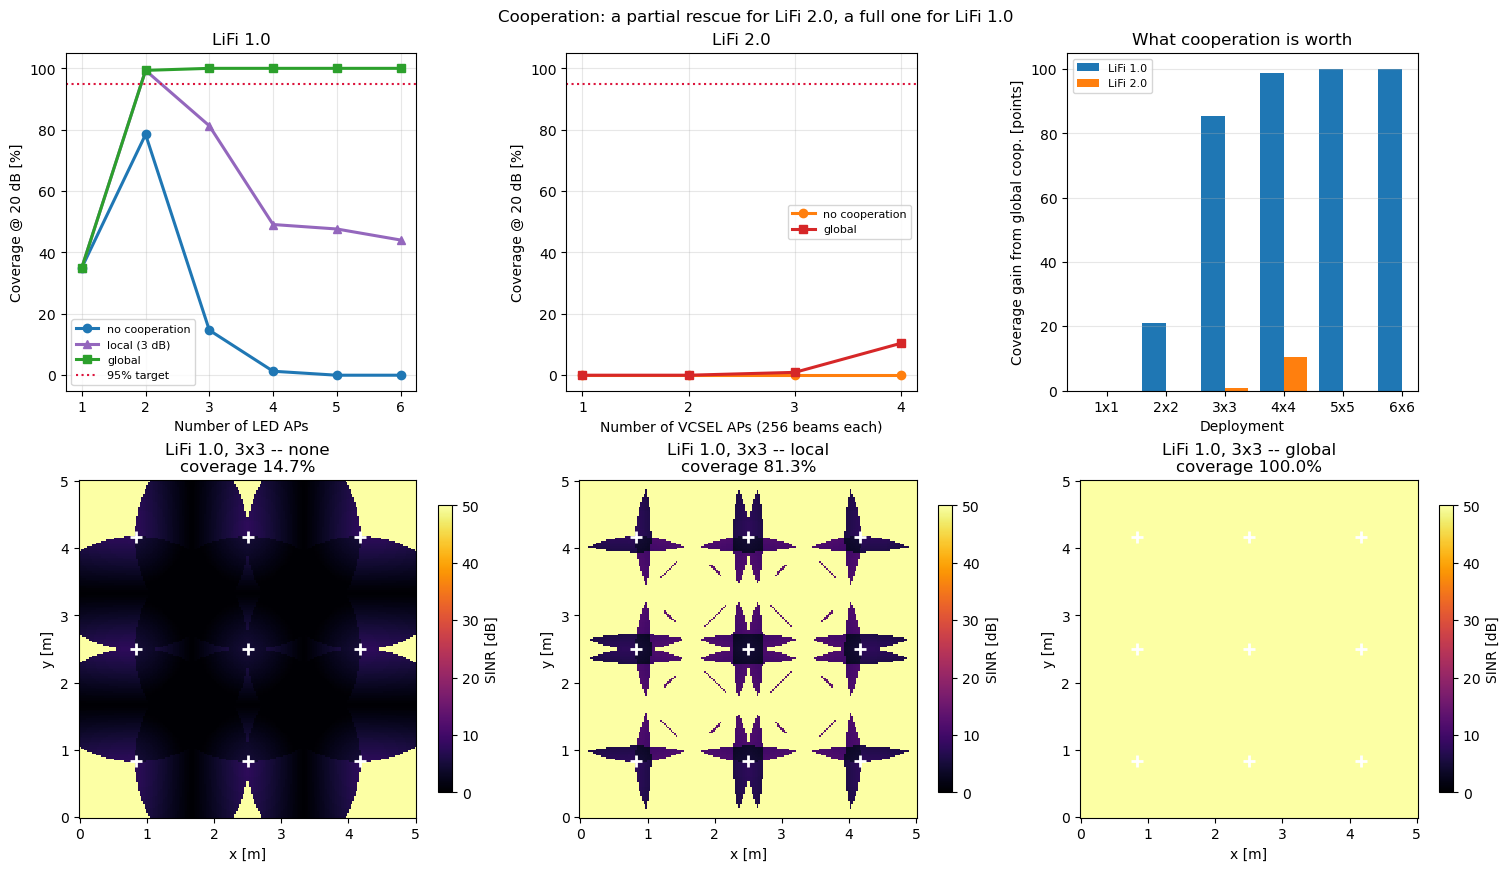

Coverage from GLOBAL cooperation (none -> global):
  LiFi 1.0 1x1:  35.1% ->  35.1%  (  +0.0 points)
  LiFi 1.0 2x2:  78.5% ->  99.3%  ( +20.9 points)
  LiFi 1.0 3x3:  14.7% -> 100.0%  ( +85.3 points)
  LiFi 1.0 4x4:   1.3% -> 100.0%  ( +98.7 points)
  LiFi 1.0 5x5:   0.0% -> 100.0%  (+100.0 points)
  LiFi 1.0 6x6:   0.0% -> 100.0%  (+100.0 points)
  LiFi 2.0 1x1:  0.00% ->  0.00%  ( +0.00 points)
  LiFi 2.0 2x2:  0.00% ->  0.00%  ( +0.00 points)
  LiFi 2.0 3x3:  0.00% ->  0.93%  ( +0.93 points)
  LiFi 2.0 4x4:  0.00% -> 10.42%  (+10.42 points)


In [11]:
ns_l, ns_v = [1, 2, 3, 4, 5, 6], [1, 2, 3, 4]
cl = {cp: [100*np.mean(evaluate_led(n, coop=cp)[0] >= GAMMA_TH) for n in ns_l]
      for cp in ["none", "local", "global"]}
cv = {cp: [100*np.mean(evaluate_vcsel(n, 16, coop=cp)[0] >= GAMMA_TH) for n in ns_v]
      for cp in ["none", "global"]}

fig = plt.figure(figsize=(15, 8.6), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# top-left: LED coverage vs density, 3 regimes
a = fig.add_subplot(gs[0, 0])
for cp, st, lb, c in [("none", "o-", "no cooperation", "tab:blue"),
                      ("local", "^-", "local (3 dB)", "tab:purple"),
                      ("global", "s-", "global", "tab:green")]:
    a.plot(ns_l, cl[cp], st, lw=2.2, ms=6, color=c, label=lb)
a.axhline(COV_TARGET, color="crimson", ls=":", lw=1.5, label="95% target")
a.set_xlabel("Number of LED APs"); a.set_ylabel("Coverage @ 20 dB [%]")
a.set_xticks(ns_l); a.set_ylim(-5, 105); a.legend(fontsize=8); a.grid(alpha=.3)
a.set_title("LiFi 1.0")

# top-middle: VCSEL
a = fig.add_subplot(gs[0, 1])
for cp, st, lb, c in [("none", "o-", "no cooperation", "tab:orange"),
                      ("global", "s-", "global", "tab:red")]:
    a.plot(ns_v, cv[cp], st, lw=2.2, ms=6, color=c, label=lb)
a.axhline(COV_TARGET, color="crimson", ls=":", lw=1.5)
a.set_xlabel("Number of VCSEL APs (256 beams each)"); a.set_ylabel("Coverage @ 20 dB [%]")
a.set_xticks(ns_v); a.set_ylim(-5, 105); a.legend(fontsize=8); a.grid(alpha=.3)
a.set_title("LiFi 2.0")

# top-right: gain bar chart
a = fig.add_subplot(gs[0, 2])
gains_l = [b-x for x, b in zip(cl["none"], cl["global"])]
gains_v = [b-x for x, b in zip(cv["none"], cv["global"])]
a.bar(np.arange(len(ns_l))-0.2, gains_l, 0.4, color="tab:blue", label="LiFi 1.0")
a.bar(np.arange(len(ns_v))+0.2, gains_v, 0.4, color="tab:orange", label="LiFi 2.0")
a.set_xticks(np.arange(len(ns_l))); a.set_xticklabels([f"{n}x{n}" for n in ns_l])
a.set_xlabel("Deployment"); a.set_ylabel("Coverage gain from global coop. [points]")
a.set_title("What cooperation is worth"); a.legend(fontsize=8); a.grid(alpha=.3, axis="y")

# bottom: LED 3x3 SINR maps, before and after cooperation
cm = plt.cm.inferno.copy(); cm.set_bad("black")
for k, cp in enumerate(["none", "local", "global"]):
    s, P, nc, _ = evaluate_led(3, coop=cp)
    a = fig.add_subplot(gs[1, k])
    dB = np.where(s > 0, 10*np.log10(np.where(s > 0, s, 1)), np.nan)
    im = a.pcolormesh(X, Y, dB, shading="auto", cmap=cm, vmin=0, vmax=50)
    a.plot(ap_lattice(3)[:, 0], ap_lattice(3)[:, 1], "w+", ms=9, mew=2)
    a.set_title(f"LiFi 1.0, 3x3 -- {cp}\ncoverage {100*np.mean(s >= GAMMA_TH):.1f}%")
    a.set_xlabel("x [m]"); a.set_ylabel("y [m]"); a.set_aspect("equal")
    fig.colorbar(im, ax=a, label="SINR [dB]", shrink=0.85)
fig.suptitle("Cooperation: a partial rescue for LiFi 2.0, a full one for LiFi 1.0")
plt.show()

print("Coverage from GLOBAL cooperation (none -> global):")
for n, a_, b_ in zip(ns_l, cl["none"], cl["global"]):
    print(f"  LiFi 1.0 {n}x{n}: {a_:5.1f}% -> {b_:5.1f}%  ({b_-a_:+6.1f} points)")
for n, a_, b_ in zip(ns_v, cv["none"], cv["global"]):
    print(f"  LiFi 2.0 {n}x{n}: {a_:5.2f}% -> {b_:5.2f}%  ({b_-a_:+6.2f} points)")

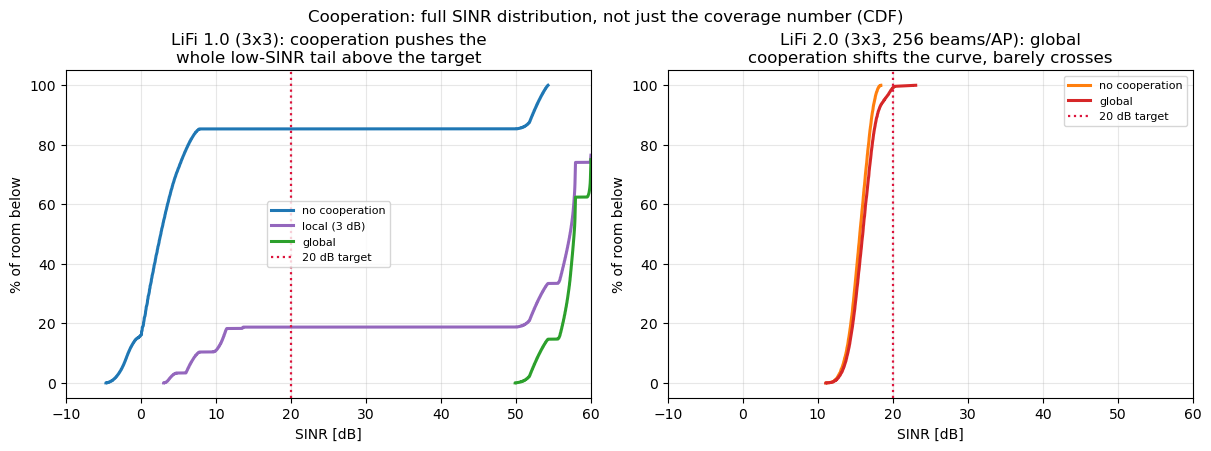

In [12]:
# same fixed deployment (LiFi 1.0, 3x3), full SINR distribution across cooperation regimes
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)

for cp, c, lb in [("none", "tab:blue", "no cooperation"), ("local", "tab:purple", "local (3 dB)"),
                  ("global", "tab:green", "global")]:
    s, _, _, _ = evaluate_led(3, coop=cp)
    d = np.sort(10 * np.log10(np.maximum(s.ravel(), 1e-12)))
    ax[0].plot(d, np.linspace(0, 100, d.size), lw=2.2, color=c, label=lb)
ax[0].axvline(GAMMA_TH_DB, color="crimson", ls=":", lw=1.6, label=f"{GAMMA_TH_DB:.0f} dB target")
ax[0].set_xlim(-10, 60); ax[0].set_xlabel("SINR [dB]"); ax[0].set_ylabel("% of room below")
ax[0].set_title("LiFi 1.0 (3x3): cooperation pushes the\nwhole low-SINR tail above the target")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

for cp, c, lb in [("none", "tab:orange", "no cooperation"), ("global", "tab:red", "global")]:
    s, _, _ = evaluate_vcsel(3, 16, coop=cp)
    d = np.sort(10 * np.log10(np.maximum(s.ravel(), 1e-12)))
    ax[1].plot(d, np.linspace(0, 100, d.size), lw=2.2, color=c, label=lb)
ax[1].axvline(GAMMA_TH_DB, color="crimson", ls=":", lw=1.6, label=f"{GAMMA_TH_DB:.0f} dB target")
ax[1].set_xlim(-10, 60); ax[1].set_xlabel("SINR [dB]"); ax[1].set_ylabel("% of room below")
ax[1].set_title("LiFi 2.0 (3x3, 256 beams/AP): global\ncooperation shifts the curve, barely crosses")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

fig.suptitle("Cooperation: full SINR distribution, not just the coverage number (CDF)")
plt.show()

* **For LiFi 1.0, cooperation is transformative.** The bottom row of maps shows it directly (the black interference bands between cells disappear), and the CDF above confirms it holds across the whole room, not just at a few points: the entire low-SINR tail moves above the target. Coverage goes from 14.7% to 100% at 3x3, and from 1.3% to 100% at 4x4: cooperation is what makes densification possible for LiFi 1.0 at all.

* **Local cooperation (3 dB) captures most of the benefit at low density, but less as the network gets denser** (99.3% at 2x2, 81.3% at 3x3, 49.1% at 4x4), because more APs end up interfering from outside the cluster. The denser the network, the bigger the clusters need to be and cluster size is what drives up synchronization and backhaul cost.

* **For LiFi 2.0, cooperation is a partial rescue, not a full one.** It does nothing at 1x1 or 2x2 (there simply aren't enough APs' amplitudes to combine into something above the 20 dB bar), but coverage moves off zero once enough APs join in: 0.93% at 3x3, 10.4% at 4x4, driven by peak SINR itself rising (18.4 dB single-beam -> 23.1 dB at 3x3 -> 25.8 dB at 4x4 global).

## 8. Results and discussion

### 8.1 Everything on one map

Cases 1-4 and Section 7 each looked at one question in isolation. The figure below collects representative deployments from all of them onto one page: four panels, one per metric, every deployment as a bar, so the two technologies can be read off side by side.


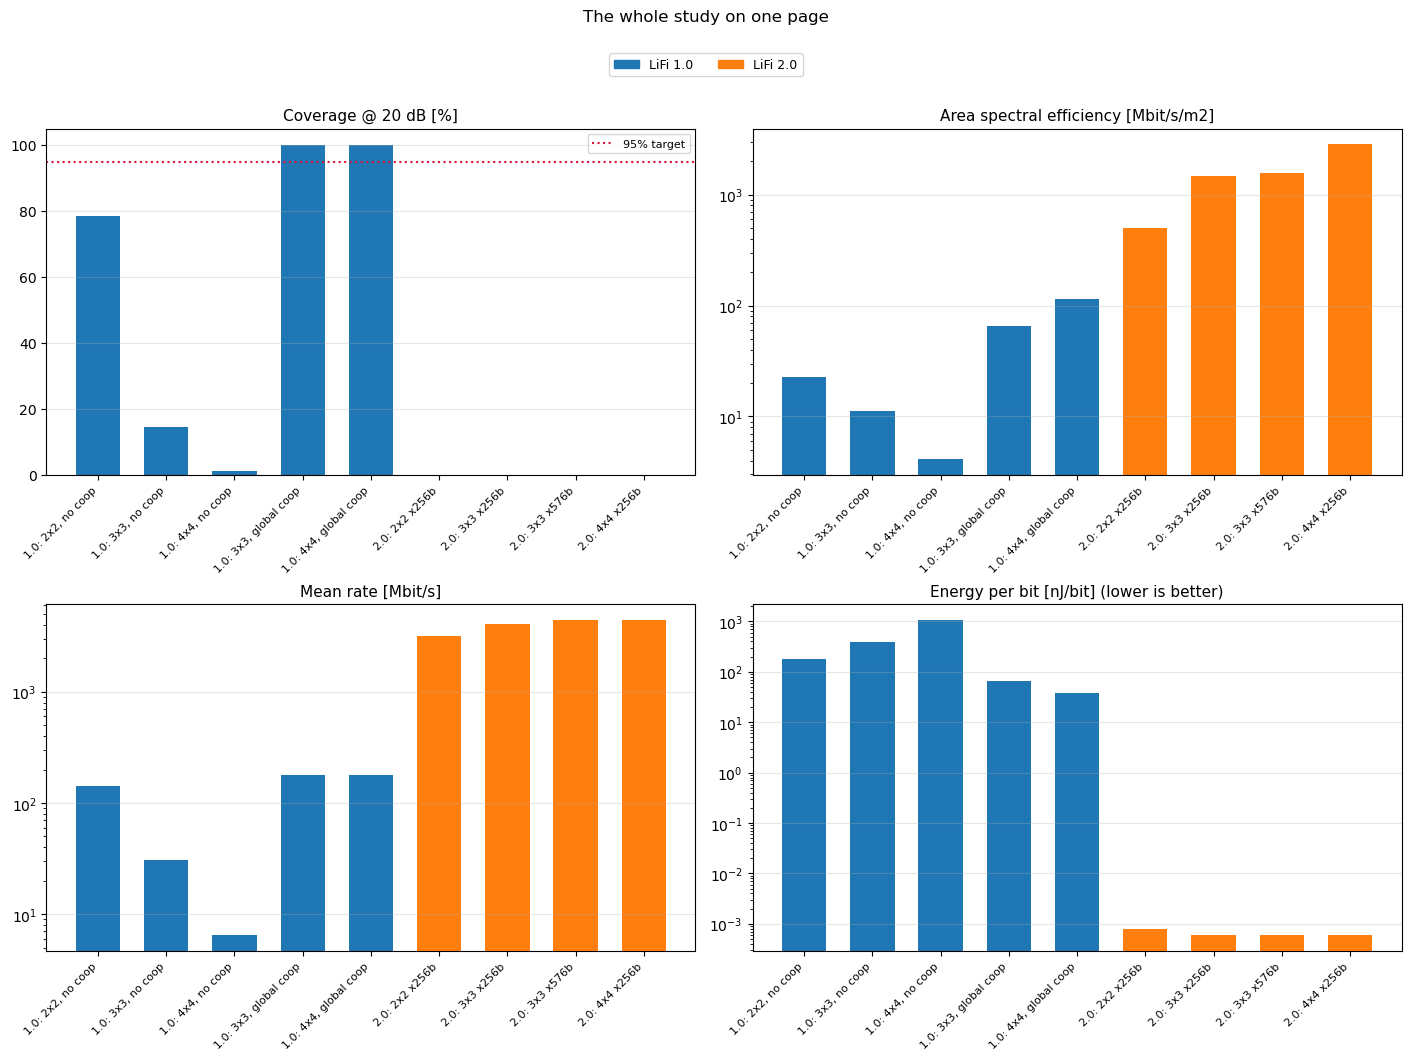

,Deployment,APs,P total [W],Coverage [%],Mean rate [Mbit/s],Cell-edge rate [Mbit/s],ASE [Mbit/s/m2],Energy/bit [nJ]
0,"1.0: 2x2, no coop",4,103.8835,78.5,143.2,6.0,22.9,181.3559
1,"1.0: 3x3, no coop",9,108.8946,14.7,30.9,3.1,11.1,391.2410
2,"1.0: 4x4, no coop",16,110.5736,1.3,6.5,2.4,4.1,1068.2005
3,"1.0: 3x3, global coop",9,108.8946,100.0,180.0,161.5,64.8,67.2011
4,"1.0: 4x4, global coop",16,110.5736,100.0,180.0,163.0,115.2,38.3968
5,2.0: 2x2 x256b,4,0.0100,0.0,3148.9,1855.3,503.8,0.0008
6,2.0: 3x3 x256b,9,0.0224,0.0,4050.0,3335.2,1458.0,0.0006
7,2.0: 3x3 x576b,9,0.0224,0.0,4387.2,3980.1,1579.4,0.0006
8,2.0: 4x4 x256b,16,0.0399,0.0,4423.4,3983.8,2831.0,0.0006


In [13]:
summary = []
for lbl, n, cp in [("1.0: 2x2, no coop", 2, "none"), ("1.0: 3x3, no coop", 3, "none"),
                   ("1.0: 4x4, no coop", 4, "none"), ("1.0: 3x3, global coop", 3, "global"),
                   ("1.0: 4x4, global coop", 4, "global")]:
    s, P, nc, _ = evaluate_led(n, coop=cp)
    r, _ = metrics(s, B_LED, P, nc, lbl, tech="LiFi 1.0"); summary.append(r)
for lbl, n, m in [("2.0: 2x2 x256b", 2, 16), ("2.0: 3x3 x256b", 3, 16),
                  ("2.0: 3x3 x576b", 3, 24), ("2.0: 4x4 x256b", 4, 16)]:
    s, P, nc = evaluate_vcsel(n, m)
    r, _ = metrics(s, B_VCSEL, P, nc, lbl, tech="LiFi 2.0", **{"Total beams": nc*m*m})
    summary.append(r)
sdf = pd.DataFrame(summary)

# grouped bar charts, one per metric -- the standard way papers in this field lay out a
# multi-configuration, multi-metric comparison (vs. the single bubble-chart alternative,
# which packs 4 dimensions into one axis and gets hard to read fast)
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5), constrained_layout=True)
colors = sdf["tech"].map({"LiFi 1.0": "tab:blue", "LiFi 2.0": "tab:orange"})
x = np.arange(len(sdf))

panels = [
    ("Coverage [%]", "Coverage @ 20 dB [%]", False),
    ("ASE [Mbit/s/m2]", "Area spectral efficiency [Mbit/s/m2]", True),
    ("Mean rate [Mbit/s]", "Mean rate [Mbit/s]", True),
    ("Energy/bit [nJ]", "Energy per bit [nJ/bit] (lower is better)", True),
]
for ax, (col, title, log_scale) in zip(axes.ravel(), panels):
    ax.bar(x, sdf[col], color=colors, width=0.65)
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks(x); ax.set_xticklabels(sdf["Deployment"], rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=.3, axis="y")
axes[0, 0].axhline(COV_TARGET, color="crimson", ls=":", lw=1.5, label="95% target")
axes[0, 0].legend(fontsize=8)

fig.legend(handles=[Patch(color="tab:blue", label="LiFi 1.0"), Patch(color="tab:orange", label="LiFi 2.0")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06), fontsize=9)
fig.suptitle("The whole study on one page", y=1.1)
plt.show()

sdf[["Deployment", "APs", "P total [W]", "Coverage [%]", "Mean rate [Mbit/s]",
     "Cell-edge rate [Mbit/s]", "ASE [Mbit/s/m2]", "Energy/bit [nJ]"]]

### 8.2 Discussion

Per watt, the two technologies look four orders of magnitude apart, but that number is misleading: the LED's watts aren't spent on communication, they light the room, which the VCSEL doesn't do at all. Communication rides for free on top of LiFi 1.0's lighting budget; for LiFi 2.0 it's the only cost there is.

Directivity explains most of the rest, but it isn't everyting: it's what makes the LED a good lamp and a poor multi-cell transmitter (its wide lobe sprays energy into every neighbouring cell), and what makes the VCSEL's cells stay isolated by geometry alone - but concentrating a fixed eye-safe power into a narrow beam still leaves that beam's own peak SNR (18.4 dB) below the 20 dB target used throughout this notebook. Directivity buys isolation and throughput; on its own, under the honest single-emitter eye-safety cap, it does not buy coverage at this threshold.

Putting the cases together, LiFi 2.0 has three real advantages, and the single-cell notebook could only see the first: bandwidth (2 GHz vs 20 MHz) opens a ~28x rate gap no LED deployment can close (Section 5); directivity gives interference-free densification for throughput and ASE; and its power isn't tied to any lighting requirement. What it does not have, under beam selection alone, is a way to clear this notebook's 20 dB coverage bar, that takes cooperation (Section 7), and even then only partially, since it has milliwatts to combine against the LED's tens of watts.

## 9. Conclusions

| Feature | LiFi 1.0 (LED) | LiFi 2.0 (VCSEL) |
|---|---|---|
| Optical source | LED | VCSEL array with beam selection |
| Emission pattern | Lambertian | Gaussian beam |
| Available power | High (tens of W, set by lighting) | Limited by eye safety (2.49 mW per emitter) |
| Directivity | Low | High |
| Single-beam coverage @ 20 dB | High (78.5% at 2x2, its lighting-driven deployment) | 0%, at every deployment tried -- a single beam's own peak SNR sits below the target (Section 3) |
| Interference | High (wide lobes overlap between cells) | Low (beams stay within their own cell) |
| Throughput | Moderate (capped by 20 MHz bandwidth) | Very high (multi-Gbit/s, 2 GHz bandwidth), even without meeting the coverage bar |
| What fixes its main gap | Cooperation (100% coverage at 3x3+) | Cooperation helps partially (10.4% at 4x4 global); full precoding is the real fix (Section 8.2) |
| Main limitation | Co-channel interference | Single-emitter eye-safety power sits below the coverage threshold this notebook uses |

LiFi 1.0 makes sense when the room needs lighting anyway and the rate requirement is modest: communication is essentially free on top of the lighting budget, and its lighting-driven 2x2 deployment already gives 78.5% coverage without coordination, 99.3% with it (100% needs 3x3 or denser, Section 7) - but within the AP densities examined here (1x1 to 6x6), it never exceeds about 143 Mbit/s of mean throughput - its own 2x2 best case (Section 3).

Under the same standards-consistent eye-safety power used in the single-cell notebook, a single selected beam never clears this notebook's 20 dB coverage bar, at any beam count - that specific metric requires cooperation, and even full cooperation only reaches 10.4% at 4x4 APs. What LiFi 2.0 does deliver, at any deployment size and a few tens of milliwatts total, is throughput: multi-gigabit mean rates and area spectral efficiencies one to two orders of magnitude above LiFi 1.0's best (Section 8.1). So the real choice is not "does LiFi 2.0 always win" but "which metric matters": for a strict per-point reliability target, it needs cooperation or true precoding; for raw capacity, it already dominates.

Cooperation is what makes LiFi 1.0 viable at high density, turning its worst enemy (interference) into useful signal, and it does the same for LiFi 2.0's coverage, just far less completely, since it has milliwatts to combine where LiFi 1.0 has tens of watts.

For 6G this points to two different roles, not one clear winner. LiFi 1.0 fits as a low-cost overlay on existing lighting infrastructure, provided its APs are coordinated. LiFi 2.0 is what scales into an ultra-dense, multi-gigabit network on throughput, but reaching this notebook's specific reliability bar with independent beams needs either cooperation across many APs or the full precoding this notebook deliberately simplified away (Section 10). The two are complementary, not competing: what makes LiFi 1.0 look weak (power dictated by lighting) is what makes it free, and what makes LiFi 2.0 look constrained (a single emitter's eye-safe power) is the direct, standards-driven reason it needs a network-level fix, not a bigger single link, to close its own coverage gap.

## 10. Limitations

The cases above compare LiFi 1.0 and LiFi 2.0 under a specific set of modelling choices. The main ones, and how they could shift the results, are listed here.

**1.** This notebook uses the realistic $w_0 = 5\ \mu m$ from `[Eye-Safety]`, not the sub-wavelength 0.45 um listed in `[VCSEL-Precoding]` Table I, and ports the resulting 2.49 mW eye-safe ceiling directly from the single-cell notebook's own calculation rather than re-deriving a nearby number. That choice sets the beam width (12 cm vs 1.34 m), the eye-safe power (2.49 mW vs an inflated 225 mW), and, as a direct consequence, the central finding that a single beam's peak SNR sits below this notebook's 20 dB target - all three have to stay consistent with each other and with the single-cell notebook.

**2. Simplified beamforming.** APs use beam selection rather than full precoding, so LiFi 2.0's results here should be read as a lower bound on what a properly precoded array could achieve.

**3. Interference under beam selection is modelled as an expected value** (an average over the interferer's beams, assuming users uniformly distributed per cell) - neither a best case nor a worst case, and the most debatable assumption in the notebook.

**4. The eye-safety budget for the array follows a specific reading of `[Eye-Safety]`.** Treating each AP as an independent budget is this notebook's own interpretation of its subtense-based classification, not a rule the paper states explicitly. The within-AP treatment is deliberately conservative - the $C_6$ relaxation for extended sources would, in principle, allow more array power than assumed here.

**5. Cooperation is idealized**, assuming perfect synchronization, perfect channel state information, and no backhaul cost, so its benefit should be read as an upper bound rather than something immediately achievable.

**6. Only one active user is modelled per AP**; multi-user scheduling within a single cell is not simulated.

**7. Both channel models are LOS only**, matching both reference papers. Adding NLOS paths would help LiFi 1.0's coverage somewhat, but it would also add to its interference.

**8. Users are static, pointing straight up, with no blockage modelled.** Random device orientation would penalize LiFi 2.0 more than LiFi 1.0, since a narrow beam is far more sensitive to misalignment than a wide Lambertian lobe. This is arguably LiFi 2.0's real weak point, and the most valuable direction for future work.

**9. Users are distributed uniformly across the room.** A more realistic distribution, concentrated around desks and seating, would favour LiFi 2.0 even further, since its whole advantage lies in aiming capacity at where users actually are.

**10. The LED's illuminance uniformity is not checked.** Each AP's power is sized to hit the 500 lux room average (and the 800 lux peak is checked, Section 3), but `[RIS-VLC]`'s uniformity constraint (C6, >= 0.5) would need optimizing AP placement or adding reflective elements, not just power which is outside the scope of a single-technology power-sizing rule. A center-fed N x N lattice sized this way does not meet it at the densities tested here; this affects only the LED's own lighting quality, not the SINR/coverage comparison the rest of this notebook is built on.

## 11. References

| Key | Paper |
|---|---|
| `[RIS-VLC]` | B. Genoves Guzman, M. Morales Cespedes, V. P. Gil Jimenez, A. Garcia Armada, M. Brandt-Pearce, *Resource Allocation Exploiting Reflective Surfaces to Minimize the Outage Probability in VLC*, IEEE Trans. Wireless Commun., vol. 24, no. 7, pp. 5493-5507, July 2025 |
| `[VCSEL-Precoding]` | H. Safi et al., *Energy-Efficient Precoding for Dense VCSEL-Based OWC Systems Under a Cooperative Broadcast Model*, IEEE GLOBECOM 2025, pp. 1113-1116 |
| `[Capacity-Bound]` | J.-B. Wang et al., *Tight Bounds on Channel Capacity for Dimmable Visible Light Communications*, J. Lightw. Technol., vol. 31, no. 23, pp. 3771-3779, Dec. 2013 |
| `[Eye-Safety]` | M. Dehghani Soltani et al., *Safety Analysis for Laser-Based Optical Wireless Communications: A Tutorial*, Proc. IEEE, vol. 110, no. 8, pp. 1045-1072, Aug. 2022 |
| `[VCSEL-70Gbps]` | H. Kazemi et al., *Achieving 70 Gb/s Over a VCSEL-Based Optical Wireless Link Using a Multimode Fibre Photoreceiver*, 2025 |

**Cited inside the reference papers, used as supporting context**:

- H. Kazemi et al., *A Novel Terabit Grid-of-Beam Optical Wireless Multi-User Access Network With Beam Clustering* -- ref. [30] of `[VCSEL-Precoding]`: the grid-of-beam architecture that the "thousands of beams" result in Section 3 points to.
- M. D. Soltani et al., *Terabit Indoor Laser-based Wireless Communications: LiFi 2.0 for 6G* -- ref. [3] of `[VCSEL-Precoding]`: the LiFi 2.0 / 6G vision referenced in the introduction.
- C. Chen, D. Tsonev, H. Haas, *Joint Transmission in Indoor VLC Downlink Cellular Networks* -- ref. [18] of `[VCSEL-Precoding]`: the joint-transmission technique modelled in Section 7.